In [1]:
import os
import re
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from matplotlib.font_manager import FontProperties
import pandas as pd
import datetime
import copy
# import scipy.stats as st
# from scipy.stats import linregress
# import seaborn as sns
import colorcet as cc
# from sklearn.neighbors import KernelDensity
# from scipy.ndimage import label, binary_dilation, generate_binary_structure, filters, iterate_structure
import warnings

In [2]:
def list_dirs(in_dir):
    """
    List sub-directories.
    """
    dirs = []
    for it in os.scandir(in_dir):
        if it.is_dir():
            dirs.append(it.path)
    return dirs

def find_lasso_files(start_dates, root_datadir, in_basename, domain):
    files = []
    # Loop over dates
    for ii in range(0, len(start_dates)):
        # Get sub-directories (cases)
        idate = start_dates[ii]
        case_dirs = list_dirs(f'{root_datadir}{idate}/')
        if len(case_dirs) > 0:
            # Loop over cases
            for icase in case_dirs:
                # Find config sub-directories
                # config_dirs = list_dirs(icase)
                config_dirs = [f'{icase}/base/']
                if len(config_dirs) > 0:
                    # Loop over configs
                    for iconfig in config_dirs:
                        # Find track stats file
                        fname = sorted(glob.glob(f'{iconfig}{domain}/stats/{in_basename}*nc'))
                        if len(fname) > 0:
                            # Replace all occurrences of double slashes with a single slash
                            _fname = re.sub(r'/+', '/', fname[0])
                            files.append(_fname)
    return files

In [3]:
# LASSO case dates
start_dates = [
    "20181129", 
    "20181204",
    "20181205", 
    "20181219", 
    "20190122", 
    "20190123",
    "20190125",
    "20190129",
    "20190208",
]

# LASSO tracking directory
rootdir_les = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/'
rootdir_meso = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/'
in_basename = 'trackstats_20'
in_basename_w = 'stats_3d_w_'
in_basename_env = 'stats_1d_env_'

figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/envs_cases/'

# Domain 4 boundaries
# lon_range = [-65.4, -63.1]
# lat_range = [-33.3, -30.8]
# lon_range = [-65., -63.1]
lon_range = [-65., -63.3]
lat_range = [-33., -30.8]
lifetime_range = [15, 1000]

# Find LASSO files
files_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename, 'd2')
files_d3 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd3')
files_d4 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd4')
# wfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_w, 'd2')
# wfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd3')
# wfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd4')
efiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_env, 'd2')
efiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd3')
efiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd4')

print(f'Number of stats files (D2): {len(files_d2)}')
# print(f'Number of W files (D2): {len(wfiles_d2)}')
print(f'Number of ENV files (D2): {len(efiles_d2)}')

print(f'Number of stats files (D3): {len(files_d3)}')
# print(f'Number of W files (D3): {len(wfiles_d3)}')
print(f'Number of ENV files (D3): {len(efiles_d3)}')

print(f'Number of stats files (D4): {len(files_d4)}')
# print(f'Number of W files (D4): {len(wfiles_d4)}')
print(f'Number of ENV files (D4): {len(efiles_d4)}')

files_d2, files_d3, files_d4, efiles_d2, efiles_d3, efiles_d4

Number of stats files (D2): 18
Number of ENV files (D2): 18
Number of stats files (D3): 18
Number of ENV files (D3): 18
Number of stats files (D4): 18
Number of ENV files (D4): 18


(['/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/20181129/gefs03/base/d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/20181129/gefs18/base/d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/20181129/gefs00/base/d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/20181129/gefs09/base/d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/20181204/gefs19/base/d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/20181204/gefs18/base/d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/20181205/gefs01/base/d2/stats/trackstats_20181205.1200_20181206.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/20181219/eda09/base/d2/stats/trackstats_20

In [4]:
_file_part = files_d2[0].strip(os.sep).split(os.sep)
print(_file_part)
print(f"Forcing: {_file_part[-5]}")

['gpfs', 'wolf2', 'arm', 'atm131', 'proj-shared', 'zfeng', 'cacti', 'meso', '20181129', 'gefs03', 'base', 'd2', 'stats', 'trackstats_20181129.1200_20181130.0000.nc']
Forcing: gefs03


In [5]:
_file_part = files_d3[10].strip(os.sep).split(os.sep)
print(_file_part)
print(f"Forcing: {_file_part[-5]}")

['gpfs', 'wolf2', 'arm', 'atm131', 'proj-shared', 'zfeng', 'cacti', 'les', '20190123', 'eda05', 'base', 'd3', 'stats', 'trackstats_20190123.1200_20190124.0000.nc']
Forcing: eda05


In [6]:
_file_part = files_d4[5].strip(os.sep).split(os.sep)
print(_file_part)
print(f"Forcing: {_file_part[-5]}")

['gpfs', 'wolf2', 'arm', 'atm131', 'proj-shared', 'zfeng', 'cacti', 'les', '20181204', 'gefs18', 'base', 'd4', 'stats', 'trackstats_20181204.1200_20181205.0000.nc']
Forcing: gefs18


## Read and combine data files

In [7]:
# Suppress the RuntimeWarning and FutureWarning from Xarray
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Initialize an empty list to hold the datasets
dst_list = []

# Loop over the track stats files and add a variable 'case'
for i, file in enumerate(files_d2):
    ds = xr.open_dataset(file)
    # Get parts from filename
    _parts = file.strip(os.sep).split(os.sep)
    _date = _parts[-6]
    _forcing = _parts[-5]
    _case = f"{_date}.{_forcing}"
    # Add a variable case (date.forcing) to the DataSet
    ds['case'] = _case
    dst_list.append(ds)

# Concatenante the DataSets along the 'tracks' dimension
dst_d2 = xr.concat(dst_list, dim='tracks')
# Renumber tracks to make it continuous
ntracks_d2 = dst_d2.sizes['tracks']
dst_d2['tracks'] = np.arange(0, ntracks_d2)

# Read ENV data (LASSO D2)
dse_d2 = xr.open_mfdataset(efiles_d2, concat_dim='tracks', combine='nested')
dse_d2['tracks'] = np.arange(0, ntracks_d2)
dse_d2 = dse_d2.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d2 = xr.combine_by_coords([dst_d2, dse_d2], combine_attrs='drop_conflicts')
ntimes_d2 = ds_d2.sizes['times']
ds_d2

<xarray.Dataset>
Dimensions:                  (tracks: 6498, times: 212, height: 101)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 6494 6495 6496 6497
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
Data variables: (12/171)
    temperature              (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_timeindex    (tracks) float64 nan nan nan nan ... nan nan 36.0
    start_split_cloudnumber  (tracks) float64 nan nan nan nan ... nan nan 1.0
    end_merge_tracknumber    (tracks) float64 nan 32.0 nan 2.0 ... 360.0 nan nan
    end_merge_timeindex      (tracks) float64 nan 10.0 nan 14.0 ... 3.0 nan nan
    end_merge_cloudnumber    (tracks) float64 nan 1.0 nan 1.0 ... 2.0 nan nan
    case                     (tracks) <U15 '20181129.gefs03' ... '20190208.ed...
Attributes:
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       2.5

In [8]:
# Suppress the RuntimeWarning and FutureWarning from Xarray
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Initialize an empty list to hold the datasets
dst_list = []

# Loop over the track stats files and add a variable 'case'
for i, file in enumerate(files_d3):
    ds = xr.open_dataset(file)
    # Get parts from filename
    _parts = file.strip(os.sep).split(os.sep)
    _date = _parts[-6]
    _forcing = _parts[-5]
    _case = f"{_date}.{_forcing}"
    # Add a variable case (date.forcing) to the DataSet
    ds['case'] = _case
    dst_list.append(ds)

# Concatenante the DataSets along the 'tracks' dimension
dst_d3 = xr.concat(dst_list, dim='tracks')
# Renumber tracks to make it continuous
ntracks_d3 = dst_d3.sizes['tracks']
dst_d3['tracks'] = np.arange(0, ntracks_d3)

# Read ENV data (LASSO d3)
dse_d3 = xr.open_mfdataset(efiles_d3, concat_dim='tracks', combine='nested')
dse_d3['tracks'] = np.arange(0, ntracks_d3)
dse_d3 = dse_d3.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d3 = xr.combine_by_coords([dst_d3, dse_d3], combine_attrs='drop_conflicts')
ntimes_d3 = ds_d3.sizes['times']
ds_d3

<xarray.Dataset>
Dimensions:                  (tracks: 11051, times: 212, height: 101)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 ... 11047 11048 11049 11050
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
Data variables: (12/171)
    temperature              (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_timeindex    (tracks) float64 nan nan nan nan ... nan 45.0 2.0
    start_split_cloudnumber  (tracks) float64 nan nan nan nan ... nan 1.0 20.0
    end_merge_tracknumber    (tracks) float64 3.0 nan nan nan ... nan nan nan
    end_merge_timeindex      (tracks) float64 5.0 nan nan nan ... nan nan nan
    end_merge_cloudnumber    (tracks) float64 1.0 nan nan nan ... nan nan nan
    case                     (tracks) <U15 '20181129.gefs03' ... '20190208.ed...
Attributes:
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [9]:
# Suppress the RuntimeWarning and FutureWarning from Xarray
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Initialize an empty list to hold the datasets
dst_list = []

# Loop over the track stats files and add a variable 'case'
for i, file in enumerate(files_d4):
    ds = xr.open_dataset(file)
    # Get parts from filename
    _parts = file.strip(os.sep).split(os.sep)
    _date = _parts[-6]
    _forcing = _parts[-5]
    _case = f"{_date}.{_forcing}"
    # Add a variable case (date.forcing) to the DataSet
    ds['case'] = _case
    dst_list.append(ds)

# Concatenante the DataSets along the 'tracks' dimension
dst_d4 = xr.concat(dst_list, dim='tracks')
# Renumber tracks to make it continuous
ntracks_d4 = dst_d4.sizes['tracks']
dst_d4['tracks'] = np.arange(0, ntracks_d4)

# Read ENV data (LASSO d4)
dse_d4 = xr.open_mfdataset(efiles_d4, concat_dim='tracks', combine='nested')
dse_d4['tracks'] = np.arange(0, ntracks_d4)
dse_d4 = dse_d4.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d4 = xr.combine_by_coords([dst_d4, dse_d4], combine_attrs='drop_conflicts')
ntimes_d4 = ds_d4.sizes['times']
ds_d4

<xarray.Dataset>
Dimensions:                  (tracks: 8824, times: 212, height: 101)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 8820 8821 8822 8823
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
Data variables: (12/171)
    temperature              (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_timeindex    (tracks) float64 nan nan nan nan ... 42.0 nan 8.0
    start_split_cloudnumber  (tracks) float64 nan nan nan nan ... 1.0 nan 1.0
    end_merge_tracknumber    (tracks) float64 nan nan 12.0 nan ... nan nan nan
    end_merge_timeindex      (tracks) float64 nan nan 1.0 nan ... nan nan nan
    end_merge_cloudnumber    (tracks) float64 nan nan 3.0 nan ... nan nan nan
    case                     (tracks) <U15 '20181129.gefs03' ... '20190208.ed...
Attributes:
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [10]:
ds_d4.where(ds_d4.case == '20190123.gefs18', drop=True)

<xarray.Dataset>
Dimensions:                  (tracks: 954, times: 212, height: 101)
Coordinates:
  * tracks                   (tracks) int64 5279 5280 5281 ... 6230 6231 6232
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
Data variables: (12/171)
    temperature              (tracks, times, height) float32 dask.array<chunksize=(954, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 dask.array<chunksize=(954, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 dask.array<chunksize=(954, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 dask.array<chunksize=(954, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 dask.array<chunksize=(954, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 dask.array<chunksize=(954, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_timeindex    (tracks) float64 nan nan nan nan ... 6.0 3.0 1.0
    start_split_cloudnumber  (tracks) float64 nan nan nan nan ... 8.0 22.0 34.0
    end_merge_tracknumber    (tracks) float64 nan nan nan nan ... nan nan nan
    end_merge_timeindex      (tracks) float64 nan nan nan nan ... nan nan nan
    end_merge_cloudnumber    (tracks) float64 nan nan nan nan ... nan nan nan
    case                     (tracks) object '20190123.gefs18' ... '20190123....
Attributes:
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [11]:
ds_d2.where(ds_d2.case == '20190208.eda08', drop=True)

<xarray.Dataset>
Dimensions:                  (tracks: 367, times: 212, height: 101)
Coordinates:
  * tracks                   (tracks) int64 6131 6132 6133 ... 6495 6496 6497
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
Data variables: (12/171)
    temperature              (tracks, times, height) float32 dask.array<chunksize=(367, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 dask.array<chunksize=(367, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 dask.array<chunksize=(367, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 dask.array<chunksize=(367, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 dask.array<chunksize=(367, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 dask.array<chunksize=(367, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_timeindex    (tracks) float64 nan nan nan nan ... nan nan 36.0
    start_split_cloudnumber  (tracks) float64 nan nan nan nan ... nan nan 1.0
    end_merge_tracknumber    (tracks) float64 21.0 nan nan nan ... 360.0 nan nan
    end_merge_timeindex      (tracks) float64 2.0 nan nan nan ... 3.0 nan nan
    end_merge_cloudnumber    (tracks) float64 1.0 nan nan nan ... 2.0 nan nan
    case                     (tracks) object '20190208.eda08' ... '20190208.e...
Attributes:
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       2.5

## Subset tracks

In [12]:
# Constents common for all Datasets
time_res = 5.0  # [min]
xtime = ds_d2.times * time_res
height = ds_d2.height / 1000.

In [13]:
# Get track min/max lat/lon
minlon_d2 = ds_d2['meanlon'].min(dim='times').load()
maxlon_d2 = ds_d2['meanlon'].max(dim='times').load()
minlat_d2 = ds_d2['meanlat'].min(dim='times').load()
maxlat_d2 = ds_d2['meanlat'].max(dim='times').load()
lifetime_d2 = (ds_d2['track_duration'] * time_res).load()
# Subset d2 tracks that are within D4 boundary
ds_d2 = ds_d2.where((minlon_d2 >= min(lon_range)) & (maxlon_d2 <= max(lon_range)) & \
                    (minlat_d2 >= min(lat_range)) & (maxlat_d2 <= max(lat_range)) & \
                    (lifetime_d2 >= min(lifetime_range) & (lifetime_d2 <= max(lifetime_range))), drop=True)
# Renumber tracks to make it continuous
ntracks_d2 = ds_d2.sizes['tracks']
ds_d2['tracks'] = np.arange(0, ntracks_d2)
print(f'Number of tracks (D2): {ntracks_d2}')

Number of tracks (D2): 3567


In [14]:
# Get track min/max lat/lon
minlon_d3 = ds_d3['meanlon'].min(dim='times').load()
maxlon_d3 = ds_d3['meanlon'].max(dim='times').load()
minlat_d3 = ds_d3['meanlat'].min(dim='times').load()
maxlat_d3 = ds_d3['meanlat'].max(dim='times').load()
lifetime_d3 = (ds_d3['track_duration'] * time_res).load()
# Subset D3 tracks that are within D4 boundary
ds_d3 = ds_d3.where((minlon_d3 >= min(lon_range)) & (maxlon_d3 <= max(lon_range)) & \
                    (minlat_d3 >= min(lat_range)) & (maxlat_d3 <= max(lat_range)) & \
                    (lifetime_d3 >= min(lifetime_range) & (lifetime_d3 <= max(lifetime_range))), drop=True)
# Renumber tracks to make it continuous
ntracks_d3 = ds_d3.sizes['tracks']
ds_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

Number of tracks (D3): 5932


In [15]:
# Get track min/max lat/lon
minlon_d4 = ds_d4['meanlon'].min(dim='times').load()
maxlon_d4 = ds_d4['meanlon'].max(dim='times').load()
minlat_d4 = ds_d4['meanlat'].min(dim='times').load()
maxlat_d4 = ds_d4['meanlat'].max(dim='times').load()
lifetime_d4 = (ds_d4['track_duration'] * time_res).load()
# Subset d4 tracks that are within D4 boundary
ds_d4 = ds_d4.where((minlon_d4 >= min(lon_range)) & (maxlon_d4 <= max(lon_range)) & \
                    (minlat_d4 >= min(lat_range)) & (maxlat_d4 <= max(lat_range)) & \
                    (lifetime_d4 >= min(lifetime_range) & (lifetime_d4 <= max(lifetime_range))), drop=True)
# Renumber tracks to make it continuous
ntracks_d4 = ds_d4.sizes['tracks']
ds_d4['tracks'] = np.arange(0, ntracks_d4)
print(f'Number of tracks (D4): {ntracks_d4}')

Number of tracks (D4): 5336


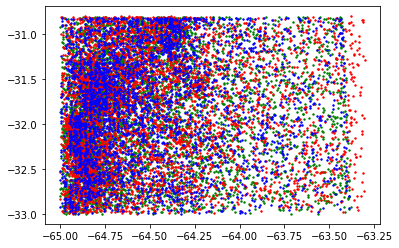

In [16]:
plt.scatter(ds_d3['meanlon'].mean(dim='times'), ds_d3['meanlat'].mean(dim='times'), s=2, c='g')
plt.scatter(ds_d4['meanlon'].mean(dim='times'), ds_d4['meanlat'].mean(dim='times'), s=2, c='r')
plt.scatter(ds_d2['meanlon'].mean(dim='times'), ds_d2['meanlat'].mean(dim='times'), s=2, c='b')

In [17]:
minlon_d4 = ds_d4['meanlon'].min().values
maxlon_d4 = ds_d4['meanlon'].max().values
minlat_d4 = ds_d4['meanlat'].min().values
maxlat_d4 = ds_d4['meanlat'].max().values
print(minlon_d4, maxlon_d4, minlat_d4, maxlat_d4)
print(lon_range, lat_range)

-64.99961 -63.304028 -32.998272 -30.800056
[-65.0, -63.3] [-33.0, -30.8]


## Find merge/split track indices

In [18]:
def find_merge_split_tracks(ds):
    """
    Find merge/split track indices.
    """
    # non-split tracks
    idx_nsplit = np.isnan(ds.start_split_cloudnumber.load())
    # non-merge tracks
    idx_nmerge = np.isnan(ds.end_merge_cloudnumber.load())
    # non-merge and non-split tracks
    idx_nms = np.isnan(ds.start_split_cloudnumber.load()) & np.isnan(ds.end_merge_cloudnumber.load())
    # merge or split tracks
    idx_ms = ~np.isnan(ds.start_split_cloudnumber.load()) | ~np.isnan(ds.end_merge_cloudnumber.load())
    # Group outputs to dictionary
    out_dict = {
        'ms': idx_ms,
        'nms': idx_nms,
        'nm': idx_nmerge,
        'ns': idx_nsplit,
    }
    return out_dict

In [19]:
tid_d2 = find_merge_split_tracks(ds_d2)
tid_d3 = find_merge_split_tracks(ds_d3)
tid_d4 = find_merge_split_tracks(ds_d4)

## Subset DataSets with non-merge/non-split tracks

In [20]:
dsnms_d2 = ds_d2.isel(tracks=tid_d2['nms'])
dsnms_d3 = ds_d3.isel(tracks=tid_d3['nms'])
dsnms_d4 = ds_d4.isel(tracks=tid_d4['nms'])

# Get number of tracks
ntracks_nms_d2 = dsnms_d2.sizes['tracks']
ntracks_nms_d3 = dsnms_d3.sizes['tracks']
ntracks_nms_d4 = dsnms_d4.sizes['tracks']
print(f'D2 non-merge-split tracks: {ntracks_nms_d2}')
print(f'D3 non-merge-split tracks: {ntracks_nms_d3}')
print(f'D4 non-merge-split tracks: {ntracks_nms_d4}')

D2 non-merge-split tracks: 1271
D3 non-merge-split tracks: 2553
D4 non-merge-split tracks: 2697


In [21]:
# Get cell track lifetime: track_duration x time_resolution [min]
track_lifetime_d2 = dsnms_d2['track_duration'].load() * time_res
track_lifetime_d3 = dsnms_d3['track_duration'].load() * time_res
track_lifetime_d4 = dsnms_d4['track_duration'].load() * time_res

# Cell max reflectivity
maxdbz_d2 = dsnms_d2['max_dbz'].load()
maxdbz_d3 = dsnms_d3['max_dbz'].load()
maxdbz_d4 = dsnms_d4['max_dbz'].load()
# Cell ETH
maxETH_10dbz_d2 = dsnms_d2['maxETH_10dbz'].load()
maxETH_10dbz_d3 = dsnms_d3['maxETH_10dbz'].load()
maxETH_10dbz_d4 = dsnms_d4['maxETH_10dbz'].load()
# Cell diameter
cellarea_d2 = dsnms_d2['cell_area'].load()
cellarea_d3 = dsnms_d3['cell_area'].load()
cellarea_d4 = dsnms_d4['cell_area'].load()
celldiam_d2 = 2 * np.sqrt(cellarea_d2 / np.pi)
celldiam_d3 = 2 * np.sqrt(cellarea_d3 / np.pi)
celldiam_d4 = 2 * np.sqrt(cellarea_d4 / np.pi)

In [22]:
# Get preCI MU LNB
preCI_time = -3  # preCI time
# Select preCI time, the drop the times coordinate (this avoids conflict with cell lifetime-max variables that has no times coordinate)
MULNB_d2 = (dsnms_d2.EL_height_mu.sel(times=preCI_time)/1000).reset_coords('times', drop=True)
MULNB_d3 = (dsnms_d3.EL_height_mu.sel(times=preCI_time)/1000).reset_coords('times', drop=True)
MULNB_d4 = (dsnms_d4.EL_height_mu.sel(times=preCI_time)/1000).reset_coords('times', drop=True)

(array([0.0007516 , 0.        , 0.00150319, 0.00225479, 0.0007516 ,
        0.0007516 , 0.00601278, 0.00977076, 0.01052236, 0.00526118,
        0.00977076, 0.00826757, 0.00601278, 0.01803833, 0.06914694,
        0.12100714, 0.16009019, 0.19391206, 0.15633221, 0.06538895,
        0.01653514, 0.03532507, 0.06012777, 0.06839534, 0.11724915,
        0.16384818, 0.13829387, 0.16009019, 0.14430665, 0.11724915,
        0.08793687, 0.04509583]),
 array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
         5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5,
        11. , 11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. ]),
 <BarContainer object of 32 artists>)

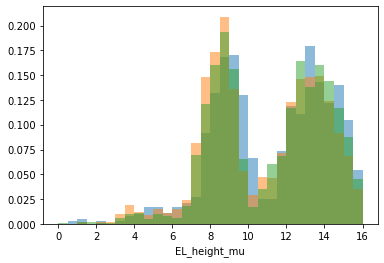

In [23]:
bins = np.arange(0, 16.1, 0.5)
MULNB_d2.plot.hist(bins=bins, alpha=0.5, label='D2', density=True)
MULNB_d3.plot.hist(bins=bins, alpha=0.5, label='D3', density=True)
MULNB_d4.plot.hist(bins=bins, alpha=0.5, label='D4', density=True)

In [24]:
dsnms_d4.where(dsnms_d4.case == '20190123.gefs18', drop=True)

<xarray.Dataset>
Dimensions:                  (tracks: 180, times: 212, height: 101)
Coordinates:
  * tracks                   (tracks) int64 3388 3389 3390 ... 3893 3900 3901
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
Data variables: (12/171)
    temperature              (tracks, times, height) float32 dask.array<chunksize=(180, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 dask.array<chunksize=(180, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 dask.array<chunksize=(180, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 dask.array<chunksize=(180, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 dask.array<chunksize=(180, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 dask.array<chunksize=(180, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_timeindex    (tracks) float64 nan nan nan nan ... nan nan nan
    start_split_cloudnumber  (tracks) float64 nan nan nan nan ... nan nan nan
    end_merge_tracknumber    (tracks) float64 nan nan nan nan ... nan nan nan
    end_merge_timeindex      (tracks) float64 nan nan nan nan ... nan nan nan
    end_merge_cloudnumber    (tracks) float64 nan nan nan nan ... nan nan nan
    case                     (tracks) object '20190123.gefs18' ... '20190123....
Attributes:
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

## Get lifetime-max cell diameter percentile values

In [25]:
ETH_percentiles = [0.33, 0.5, 0.66]
trackmaxETH_10dbz_d2 = maxETH_10dbz_d2.max(dim='times')
max10dbz_pts_d2 = trackmaxETH_10dbz_d2.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ percentile values (D2): {max10dbz_pts_d2.values}")

trackmaxCellDiam_d2 = celldiam_d2.max(dim='times')
maxCellDiam_pts_d2 = trackmaxCellDiam_d2.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max CellDiam percentile values (D2): {maxCellDiam_pts_d2.values}")

Max 10dBZ percentile values (D2): [4.   4.75 6.  ]
Max CellDiam percentile values (D2): [ 9.7720499  10.17107201 11.96826839]


In [26]:
trackmaxETH_10dbz_d3 = maxETH_10dbz_d3.max(dim='times')
max10dbz_pts_d3 = trackmaxETH_10dbz_d3.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ percentile values (D3): {max10dbz_pts_d3.values}")

trackmaxCellDiam_d3 = celldiam_d3.max(dim='times')
maxCellDiam_pts_d3 = trackmaxCellDiam_d3.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max CellDiam percentile values (D3): {maxCellDiam_pts_d3.values}")

Max 10dBZ percentile values (D3): [5.25 6.   7.  ]
Max CellDiam percentile values (D3): [4.95074368 5.58519173 6.635397  ]


In [27]:
trackmaxETH_10dbz_d4 = maxETH_10dbz_d4.max(dim='times')
max10dbz_pts_d4 = trackmaxETH_10dbz_d4.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ percentile values (D4): {max10dbz_pts_d4.values}")

trackmaxCellDiam_d4 = celldiam_d4.max(dim='times')
maxCellDiam_pts_d4 = trackmaxCellDiam_d4.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max CellDiam percentile values (D4): {maxCellDiam_pts_d4.values}")

Max 10dBZ percentile values (D4): [5.  5.5 6.5]
Max CellDiam percentile values (D4): [4.90810179 5.41151619 6.28254938]


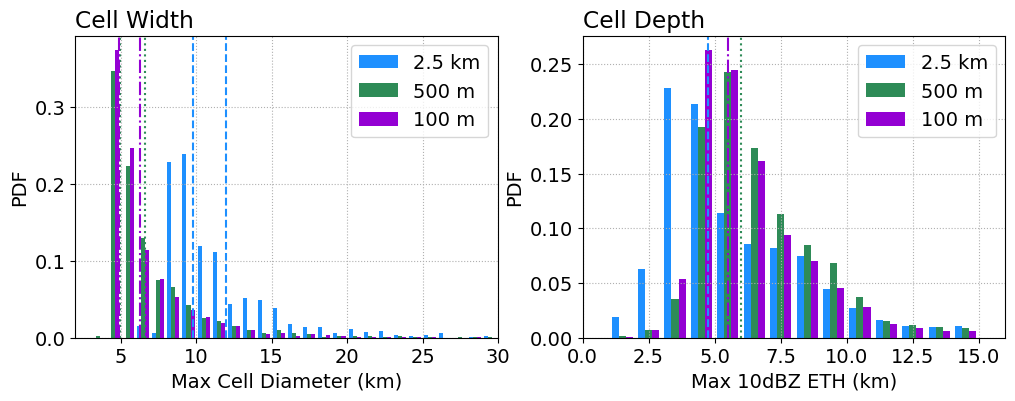

In [28]:
mpl.rcParams['font.size'] = 14
# mpl.rcParams['font.family'] = 'Helvetica'

fig, axes = plt.subplots(1, 2, figsize=(12,4), dpi=100)
lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}

ax = axes[0]
bins = np.arange(2, 31, 1)
bar_data = [trackmaxCellDiam_d2, trackmaxCellDiam_d3, trackmaxCellDiam_d4]
bar_labels = list(name_map.values())
bar_colors = list(lcolors.values())
ax.hist(bar_data, bins=bins, alpha=1, label=bar_labels, histtype='bar', color=bar_colors, density=True)
ax.legend()
# Percentile lines
ax.axvline(maxCellDiam_pts_d2.sel(quantile=0.33), ls='--', color=lcolors['d2'],)
ax.axvline(maxCellDiam_pts_d2.sel(quantile=0.66), ls='--', color=lcolors['d2'],)
ax.axvline(maxCellDiam_pts_d3.sel(quantile=0.33), ls=':', color=lcolors['d3'],)
ax.axvline(maxCellDiam_pts_d3.sel(quantile=0.66), ls=':', color=lcolors['d3'],)
ax.axvline(maxCellDiam_pts_d4.sel(quantile=0.33), ls='dashdot', color=lcolors['d4'],)
ax.axvline(maxCellDiam_pts_d4.sel(quantile=0.66), ls='dashdot', color=lcolors['d4'],)
ax.set_xlim((2,30))
ax.set_xlabel('Max Cell Diameter (km)')
ax.set_ylabel('PDF')
ax.set_title('Cell Width', loc='left')
ax.grid(ls=':')

ax = axes[1]
bins = np.arange(0, 16, 1)
bar_data = [trackmaxETH_10dbz_d2, trackmaxETH_10dbz_d3, trackmaxETH_10dbz_d4]
ax.hist(bar_data, bins=bins, alpha=1, label=bar_labels, histtype='bar', color=bar_colors, density=True)

# Percentile lines
ax.axvline(max10dbz_pts_d2.sel(quantile=0.5), ls='--', color=lcolors['d2'],)
# ax.axvline(max10dbz_pts_d2.sel(quantile=0.66), ls='--', color=lcolors['d2'],)
ax.axvline(max10dbz_pts_d3.sel(quantile=0.5), ls=':', color=lcolors['d3'],)
# ax.axvline(max10dbz_pts_d3.sel(quantile=0.66), ls=':', color=lcolors['d3'],)
ax.axvline(max10dbz_pts_d4.sel(quantile=0.5), ls='dashdot', color=lcolors['d4'],)
# ax.axvline(max10dbz_pts_d4.sel(quantile=0.66), ls='dashdot', color=lcolors['d4'],)
ax.legend()
ax.set_xlim((0,16))
ax.set_xlabel('Max 10dBZ ETH (km)')
ax.set_ylabel('PDF')
ax.set_title('Cell Depth', loc='left')
ax.grid(ls=':')

# figname = f'{figdir}PDF_maxCellDiam_maxETH10dBZ_d2_d3_d4.png'
# fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

## Separate narrow vs. wide cell DataSets

In [29]:
# MU LNB threshold, cells must have LNB > this to be retained in the subsequent analysis
MULNB_thresh = 6.0  # [km]

In [30]:
# Define narrow vs. wide thresholds
narrow_diam_d2 = maxCellDiam_pts_d2.sel(quantile=0.33).item()
wide_diam_d2 = maxCellDiam_pts_d2.sel(quantile=0.66).item()
print(f'Narrow diameter threshold (D2): {narrow_diam_d2:.01f} km')
print(f'Wide diameter threshold (D2): {wide_diam_d2:.01f} km')

# Separate narrow vs. wide cell DataSets, also require LNB > MULNB_thresh
narrow_tracks_d2 = ((trackmaxCellDiam_d2 <= narrow_diam_d2) & (MULNB_d2 > MULNB_thresh)).compute()
wide_tracks_d2 = ((trackmaxCellDiam_d2 >= wide_diam_d2) & (MULNB_d2 > MULNB_thresh)).compute()
# Subset DataSets
ds_narrow_d2 = dsnms_d2.where(narrow_tracks_d2, drop=True)
ds_wide_d2 = dsnms_d2.where(wide_tracks_d2, drop=True)
ntracks_narrow_d2 = ds_narrow_d2.sizes['tracks']
ntracks_wide_d2 = ds_wide_d2.sizes['tracks']
print(f'Number of narrow cells (D2): {ntracks_narrow_d2}')
print(f'Number of wide cells (D2): {ntracks_wide_d2}')

# Get cell track lifetime: track_duration x time_resolution [min]
narrow_track_lifetime_d2 = ds_narrow_d2.track_duration * time_res
wide_track_lifetime_d2 = ds_wide_d2.track_duration * time_res
# Lifetime-max reflectivity
narrow_maxdbz_d2 = ds_narrow_d2.max_dbz.max(dim='times')
wide_maxdbz_d2 = ds_wide_d2.max_dbz.max(dim='times')
# Lifetime-max 10dBZ ETH
narrow_maxETH10dbz_d2 = ds_narrow_d2.maxETH_10dbz.max(dim='times')
wide_maxETH10dbz_d2 = ds_wide_d2.maxETH_10dbz.max(dim='times')

Narrow diameter threshold (D2): 9.8 km
Wide diameter threshold (D2): 12.0 km
Number of narrow cells (D2): 588
Number of wide cells (D2): 446


In [31]:
# Define narrow vs. wide thresholds
narrow_diam_d3 = maxCellDiam_pts_d3.sel(quantile=0.33).item()
wide_diam_d3 = maxCellDiam_pts_d3.sel(quantile=0.66).item()
print(f'Narrow diameter threshold (D3): {narrow_diam_d3:.01f} km')
print(f'Wide diameter threshold (D3): {wide_diam_d3:.01f} km')

# Separate narrow vs. wide cell DataSets, also require LNB > MULNB_thresh
narrow_tracks_d3 = ((trackmaxCellDiam_d3 <= narrow_diam_d3) & (MULNB_d3 > MULNB_thresh)).compute()
wide_tracks_d3 = ((trackmaxCellDiam_d3 >= wide_diam_d3) & (MULNB_d3 > MULNB_thresh)).compute()
# Subset DataSets
ds_narrow_d3 = dsnms_d3.where(narrow_tracks_d3, drop=True)
ds_wide_d3 = dsnms_d3.where(wide_tracks_d3, drop=True)
ntracks_narrow_d3 = ds_narrow_d3.sizes['tracks']
ntracks_wide_d3 = ds_wide_d3.sizes['tracks']
print(f'Number of narrow cells (D3): {ntracks_narrow_d3}')
print(f'Number of wide cells (D3): {ntracks_wide_d3}')

# Get cell track lifetime: track_duration x time_resolution [min]
narrow_track_lifetime_d3 = ds_narrow_d3.track_duration * time_res
wide_track_lifetime_d3 = ds_wide_d3.track_duration * time_res
# Lifetime-max reflectivity
narrow_maxdbz_d3 = ds_narrow_d3.max_dbz.max(dim='times')
wide_maxdbz_d3 = ds_wide_d3.max_dbz.max(dim='times')
# Lifetime-max 10dBZ ETH
narrow_maxETH10dbz_d3 = ds_narrow_d3.maxETH_10dbz.max(dim='times')
wide_maxETH10dbz_d3 = ds_wide_d3.maxETH_10dbz.max(dim='times')

Narrow diameter threshold (D3): 5.0 km
Wide diameter threshold (D3): 6.6 km
Number of narrow cells (D3): 824
Number of wide cells (D3): 823


In [32]:
# Define narrow vs. wide thresholds
narrow_diam_d4 = maxCellDiam_pts_d4.sel(quantile=0.33).item()
wide_diam_d4 = maxCellDiam_pts_d4.sel(quantile=0.66).item()
print(f'Narrow diameter threshold (D4): {narrow_diam_d4:.01f} km')
print(f'Wide diameter threshold (D4): {wide_diam_d4:.01f} km')

# Separate narrow vs. wide cell DataSets, also require LNB > MULNB_thresh
narrow_tracks_d4 = ((trackmaxCellDiam_d4 <= narrow_diam_d4) & (MULNB_d4 > MULNB_thresh)).compute()
wide_tracks_d4 = ((trackmaxCellDiam_d4 >= wide_diam_d4) & (MULNB_d4 > MULNB_thresh)).compute()
# Subset DataSets
ds_narrow_d4 = dsnms_d4.where(narrow_tracks_d4, drop=True)
ds_wide_d4 = dsnms_d4.where(wide_tracks_d4, drop=True)
ntracks_narrow_d4 = ds_narrow_d4.sizes['tracks']
ntracks_wide_d4 = ds_wide_d4.sizes['tracks']
print(f'Number of narrow cells (D4): {ntracks_narrow_d4}')
print(f'Number of wide cells (D4): {ntracks_wide_d4}')

# Get cell track lifetime: track_duration x time_resolution [min]
narrow_track_lifetime_d4 = ds_narrow_d4.track_duration * time_res
wide_track_lifetime_d4 = ds_wide_d4.track_duration * time_res
# Lifetime-max reflectivity
narrow_maxdbz_d4 = ds_narrow_d4.max_dbz.max(dim='times')
wide_maxdbz_d4 = ds_wide_d4.max_dbz.max(dim='times')
# Lifetime-max 10dBZ ETH
narrow_maxETH10dbz_d4 = ds_narrow_d4.maxETH_10dbz.max(dim='times')
wide_maxETH10dbz_d4 = ds_wide_d4.maxETH_10dbz.max(dim='times')

Narrow diameter threshold (D4): 4.9 km
Wide diameter threshold (D4): 6.3 km
Number of narrow cells (D4): 866
Number of wide cells (D4): 875


(array([ 4.,  3., 12., 19., 22., 24., 23., 35., 28.,  7.]),
 array([11.1     , 11.552   , 12.004001, 12.456   , 12.908   , 13.360001,
        13.812   , 14.264   , 14.716   , 15.168   , 15.62    ],
       dtype=float32),
 <BarContainer object of 10 artists>)

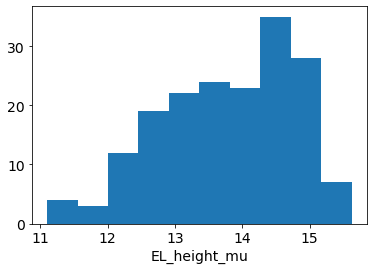

In [33]:
MULNB_d4.where(dsnms_d4.case == '20190123.gefs18', drop=True).plot.hist()

In [34]:
ds_wide_d4.where(ds_wide_d4.case == '20190123.gefs18', drop=True)

<xarray.Dataset>
Dimensions:                  (tracks: 76, times: 212, height: 101)
Coordinates:
  * tracks                   (tracks) int64 3407 3417 3420 ... 3883 3900 3901
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
Data variables: (12/171)
    temperature              (tracks, times, height) float32 dask.array<chunksize=(76, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 dask.array<chunksize=(76, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 dask.array<chunksize=(76, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 dask.array<chunksize=(76, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 dask.array<chunksize=(76, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 dask.array<chunksize=(76, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_timeindex    (tracks) float64 nan nan nan nan ... nan nan nan
    start_split_cloudnumber  (tracks) float64 nan nan nan nan ... nan nan nan
    end_merge_tracknumber    (tracks) float64 nan nan nan nan ... nan nan nan
    end_merge_timeindex      (tracks) float64 nan nan nan nan ... nan nan nan
    end_merge_cloudnumber    (tracks) float64 nan nan nan nan ... nan nan nan
    case                     (tracks) object '20190123.gefs18' ... '20190123....
Attributes:
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [35]:
# Get unique case names
uniq_cases = np.unique(dsnms_d4.case)
uniq_cases

array(['20181129.gefs00', '20181129.gefs03', '20181129.gefs09',
       '20181129.gefs18', '20181204.gefs18', '20181204.gefs19',
       '20181205.gefs01', '20181219.eda09', '20190122.gefs01',
       '20190122.gefs18', '20190123.eda05', '20190123.gefs18',
       '20190125.eda07', '20190125.gefs11', '20190129.eda09',
       '20190129.gefs11', '20190208.eda03', '20190208.eda08'],
      dtype=object)

In [36]:
# Convert case names to upper case
uniq_CASES = [s.upper() for s in uniq_cases]
uniq_CASES

['20181129.GEFS00',
 '20181129.GEFS03',
 '20181129.GEFS09',
 '20181129.GEFS18',
 '20181204.GEFS18',
 '20181204.GEFS19',
 '20181205.GEFS01',
 '20181219.EDA09',
 '20190122.GEFS01',
 '20190122.GEFS18',
 '20190123.EDA05',
 '20190123.GEFS18',
 '20190125.EDA07',
 '20190125.GEFS11',
 '20190129.EDA09',
 '20190129.GEFS11',
 '20190208.EDA03',
 '20190208.EDA08']

In [37]:
ntracks_case_narrow_d2 = []
ntracks_case_narrow_d3 = []
ntracks_case_narrow_d4 = []
for icase in uniq_cases:
    # print(icase)
    ntracks_case_narrow_d2.append(ds_narrow_d2.tracks.where(ds_narrow_d2.case == icase, drop=True).sizes['tracks'])
    ntracks_case_narrow_d3.append(ds_narrow_d3.tracks.where(ds_narrow_d3.case == icase, drop=True).sizes['tracks'])
    ntracks_case_narrow_d4.append(ds_narrow_d4.tracks.where(ds_narrow_d4.case == icase, drop=True).sizes['tracks'])

In [38]:
ntracks_case_wide_d2 = []
ntracks_case_wide_d3 = []
ntracks_case_wide_d4 = []
for icase in uniq_cases:
    # print(icase)
    ntracks_case_wide_d2.append(ds_wide_d2.tracks.where(ds_wide_d2.case == icase, drop=True).sizes['tracks'])
    ntracks_case_wide_d3.append(ds_wide_d3.tracks.where(ds_wide_d3.case == icase, drop=True).sizes['tracks'])
    ntracks_case_wide_d4.append(ds_wide_d4.tracks.where(ds_wide_d4.case == icase, drop=True).sizes['tracks'])

In [39]:
for idate in start_dates:
    print(idate)

20181129
20181204
20181205
20181219
20190122
20190123
20190125
20190129
20190208


In [40]:
ntracks_date_narrow_d2 = []
ntracks_date_narrow_d3 = []
ntracks_date_narrow_d4 = []

for idate in start_dates:
    # print(idate)
    ntracks_date_narrow_d2.append(ds_narrow_d2.tracks.where(ds_narrow_d2.start_basetime.dt.strftime('%Y%m%d') == idate, drop=True).sizes['tracks'])
    ntracks_date_narrow_d3.append(ds_narrow_d3.tracks.where(ds_narrow_d3.start_basetime.dt.strftime('%Y%m%d') == idate, drop=True).sizes['tracks'])
    ntracks_date_narrow_d4.append(ds_narrow_d4.tracks.where(ds_narrow_d4.start_basetime.dt.strftime('%Y%m%d') == idate, drop=True).sizes['tracks'])

In [41]:
ntracks_date_wide_d2 = []
ntracks_date_wide_d3 = []
ntracks_date_wide_d4 = []

for idate in start_dates:
    # print(idate)
    ntracks_date_wide_d2.append(ds_wide_d2.tracks.where(ds_wide_d2.start_basetime.dt.strftime('%Y%m%d') == idate, drop=True).sizes['tracks'])
    ntracks_date_wide_d3.append(ds_wide_d3.tracks.where(ds_wide_d3.start_basetime.dt.strftime('%Y%m%d') == idate, drop=True).sizes['tracks'])
    ntracks_date_wide_d4.append(ds_wide_d4.tracks.where(ds_wide_d4.start_basetime.dt.strftime('%Y%m%d') == idate, drop=True).sizes['tracks'])

In [42]:
# plt.bar(uniq_cases, ntracks_case_narrow_d2)
# plt.xticks(rotation=90)

In [43]:
def plot_bars(bar_data, xlabel=None, ylabel=None, title=None, figsize=None, figname=None, bold_xlabel=True):
    plt.rcParams['font.family'] = 'DejaVu Serif'

    x = np.arange(len(xlabel))  # the label locations
    width = 0.2  # the width of the bars
    lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
    name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}

    fig, ax = plt.subplots(figsize=figsize, dpi=100)
    bars2 = ax.bar(x - width, bar_data['d2'], width, label=name_map['d2'], color=lcolors['d2'])
    bars3 = ax.bar(x, bar_data['d3'], width, label=name_map['d3'], color=lcolors['d3'])
    bars4 = ax.bar(x + width, bar_data['d4'], width, label=name_map['d4'], color=lcolors['d4'])

    # Create font properties
    bold_font = FontProperties(weight='bold', family='Helvetica')
    regular_font = FontProperties(weight='normal', family='Helvetica')

    if bold_xlabel:
        # Function to format labels
        def format_label(label):
            parts = label.split('.')
            return f"$\\bf{{{parts[0]}}}$.{parts[1]}"

        # Format xlabels
        formatted_xlabels = [format_label(label) for label in xlabel]
    else:
        formatted_xlabels = xlabel

    # Add some text for labels, title and custom x-axis tick labels, etc.
    # ax.set_xlabel('Cases')
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc='left')
    ax.set_xticks(x)
    ax.set_xticklabels(formatted_xlabels, rotation=30, ha='right')
    ax.grid(ls=':', axis='y')
    ax.legend()

    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

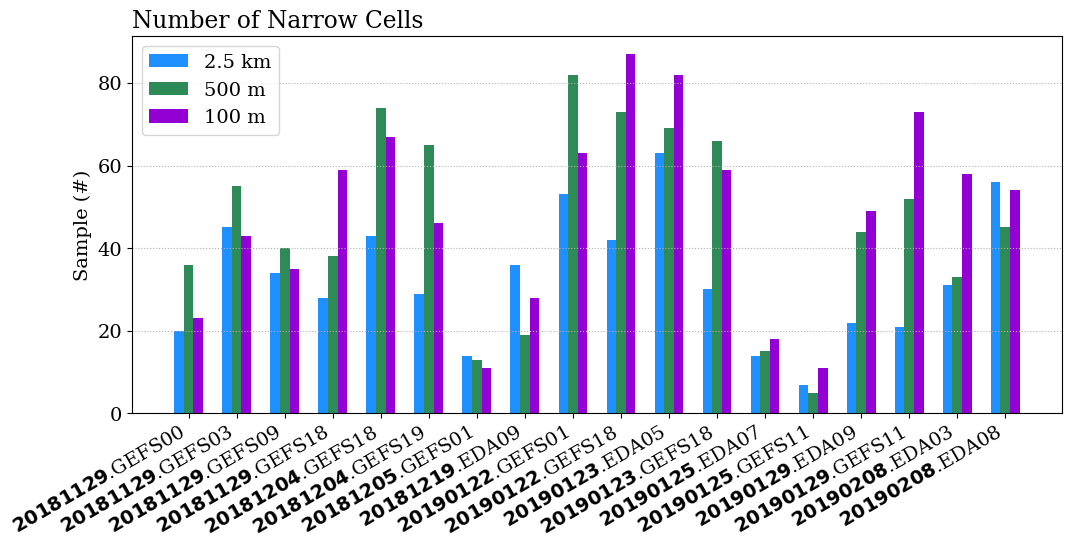

In [44]:
x = np.arange(len(uniq_CASES))
bar_data = {'d2':ntracks_case_narrow_d2, 'd3':ntracks_case_narrow_d3, 'd4':ntracks_case_narrow_d4}
ylabel = 'Sample (#)'
title = 'Number of Narrow Cells'
figsize = [12,5]
figname = f'{figdir}CellNumberByCase_narrow_d2_d3_d4.png'
fig = plot_bars(bar_data, xlabel=uniq_CASES, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

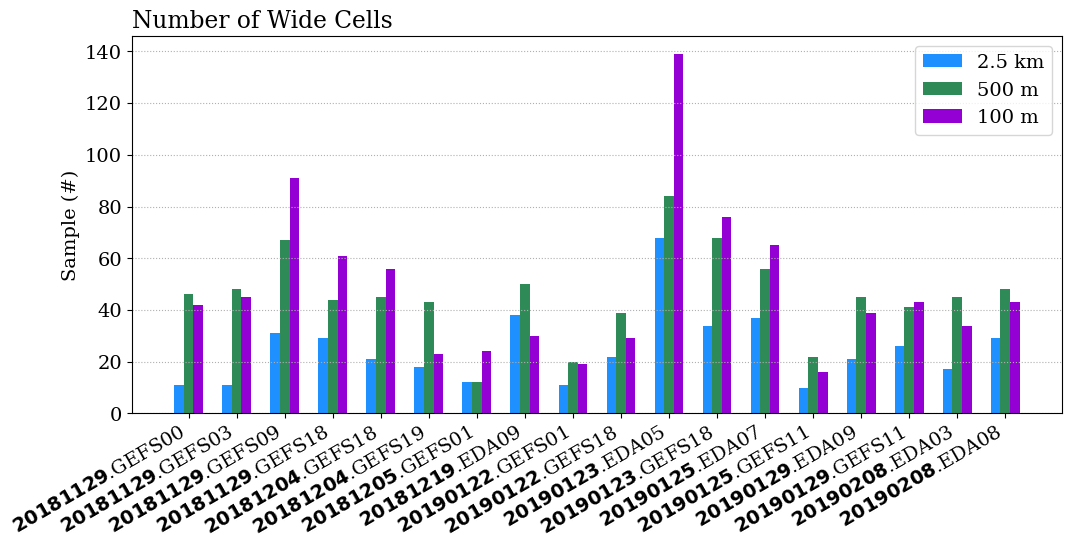

In [45]:
x = np.arange(len(uniq_CASES))
bar_data = {'d2':ntracks_case_wide_d2, 'd3':ntracks_case_wide_d3, 'd4':ntracks_case_wide_d4}
ylabel = 'Sample (#)'
title = 'Number of Wide Cells'
figsize = [12,5]
figname = f'{figdir}CellNumberByCase_wide_d2_d3_d4.png'
fig = plot_bars(bar_data, xlabel=uniq_CASES, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

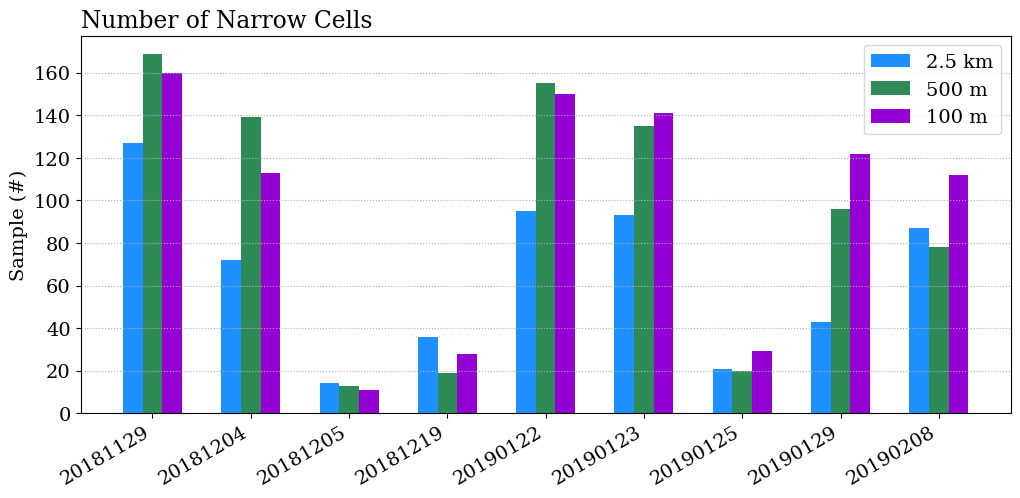

In [46]:
x = np.arange(len(start_dates))
bar_data = {'d2':ntracks_date_narrow_d2, 'd3':ntracks_date_narrow_d3, 'd4':ntracks_date_narrow_d4}
ylabel = 'Sample (#)'
title = 'Number of Narrow Cells'
figsize = [12,5]
figname = f'{figdir}CellNumberByDate_narrow_d2_d3_d4.png'
fig = plot_bars(bar_data, xlabel=start_dates, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=False)

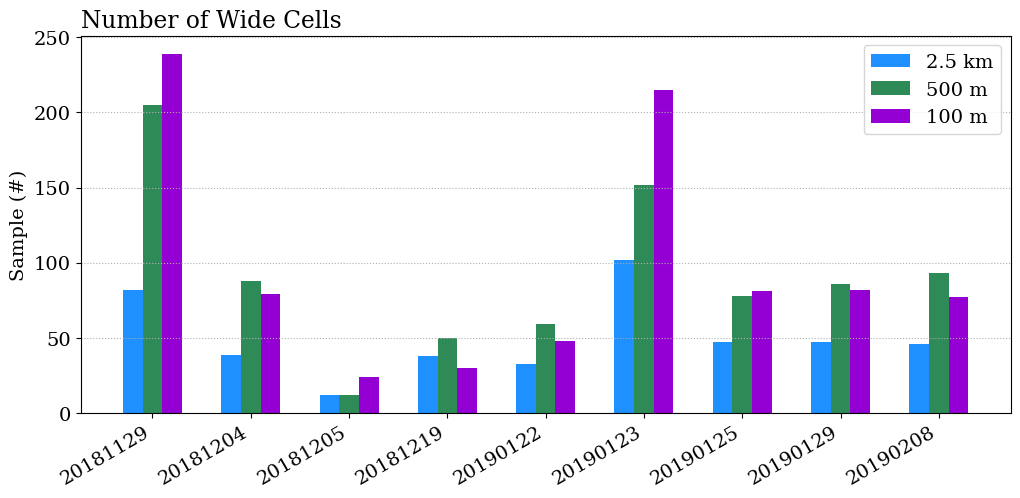

In [47]:
x = np.arange(len(start_dates))
bar_data = {'d2':ntracks_date_wide_d2, 'd3':ntracks_date_wide_d3, 'd4':ntracks_date_wide_d4}
ylabel = 'Sample (#)'
title = 'Number of Wide Cells'
figsize = [12,5]
figname = f'{figdir}CellNumberByDate_wide_d2_d3_d4.png'
fig = plot_bars(bar_data, xlabel=start_dates, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=False)

# Get environmental variables for each date in lists

In [48]:
def get_var_by_date(ds, varname, preCI_t, scale=1.0):
    var_out = []
    for idate in start_dates:
        var_out.append(ds[varname].where(ds.start_basetime.dt.strftime('%Y%m%d') == idate, drop=True).sel(times=preCI_t).reset_coords('times', drop=True) * scale)
    return var_out

In [49]:
preCI_t = -3  # preCI time to get a single value

pELmu_date_wide_d2 = get_var_by_date(ds_wide_d2, 'pEL_height_mu', preCI_t, scale=1e-3)
pELmu_date_wide_d3 = get_var_by_date(ds_wide_d3, 'pEL_height_mu', preCI_t, scale=1e-3)
pELmu_date_wide_d4 = get_var_by_date(ds_wide_d4, 'pEL_height_mu', preCI_t, scale=1e-3)

pCAPEmu_date_wide_d2 = get_var_by_date(ds_wide_d2, 'pCAPE_mu', preCI_t)
pCAPEmu_date_wide_d3 = get_var_by_date(ds_wide_d3, 'pCAPE_mu', preCI_t)
pCAPEmu_date_wide_d4 = get_var_by_date(ds_wide_d4, 'pCAPE_mu', preCI_t)

pCAPEacbl_date_wide_d2 = get_var_by_date(ds_wide_d2, 'pCAPEacbl_ml', preCI_t)
pCAPEacbl_date_wide_d3 = get_var_by_date(ds_wide_d3, 'pCAPEacbl_ml', preCI_t)
pCAPEacbl_date_wide_d4 = get_var_by_date(ds_wide_d4, 'pCAPEacbl_ml', preCI_t)

pLCLz_date_wide_d2 = get_var_by_date(ds_wide_d2, 'LCL_height_mu', preCI_t, scale=1e-3)
pLCLz_date_wide_d3 = get_var_by_date(ds_wide_d3, 'LCL_height_mu', preCI_t, scale=1e-3)
pLCLz_date_wide_d4 = get_var_by_date(ds_wide_d4, 'LCL_height_mu', preCI_t, scale=1e-3)

pLFCz_date_wide_d2 = get_var_by_date(ds_wide_d2, 'LFC_height_mu', preCI_t, scale=1e-3)
pLFCz_date_wide_d3 = get_var_by_date(ds_wide_d3, 'LFC_height_mu', preCI_t, scale=1e-3)
pLFCz_date_wide_d4 = get_var_by_date(ds_wide_d4, 'LFC_height_mu', preCI_t, scale=1e-3)

RHacbl_date_wide_d2 = get_var_by_date(ds_wide_d2, 'RH_mean_ACBL', preCI_t)
RHacbl_date_wide_d3 = get_var_by_date(ds_wide_d3, 'RH_mean_ACBL', preCI_t)
RHacbl_date_wide_d4 = get_var_by_date(ds_wide_d4, 'RH_mean_ACBL', preCI_t)

RH500mb_date_wide_d2 = get_var_by_date(ds_wide_d2, 'rh_500mb', preCI_t)
RH500mb_date_wide_d3 = get_var_by_date(ds_wide_d3, 'rh_500mb', preCI_t)
RH500mb_date_wide_d4 = get_var_by_date(ds_wide_d4, 'rh_500mb', preCI_t)

RHlfc1500_date_wide_d2 = get_var_by_date(ds_wide_d2, 'rh_at_pmuLFCplus1500m', preCI_t)
RHlfc1500_date_wide_d3 = get_var_by_date(ds_wide_d3, 'rh_at_pmuLFCplus1500m', preCI_t)
RHlfc1500_date_wide_d4 = get_var_by_date(ds_wide_d4, 'rh_at_pmuLFCplus1500m', preCI_t)

PW_date_wide_d2 = get_var_by_date(ds_wide_d2, 'PW', preCI_t)
PW_date_wide_d3 = get_var_by_date(ds_wide_d3, 'PW', preCI_t)
PW_date_wide_d4 = get_var_by_date(ds_wide_d4, 'PW', preCI_t)

BWSacbl_date_wide_d2 = get_var_by_date(ds_wide_d2, 'shear_mag_bulk_ACBL_mu', preCI_t)
BWSacbl_date_wide_d3 = get_var_by_date(ds_wide_d3, 'shear_mag_bulk_ACBL_mu', preCI_t)
BWSacbl_date_wide_d4 = get_var_by_date(ds_wide_d4, 'shear_mag_bulk_ACBL_mu', preCI_t)

BWS03km_date_wide_d2 = get_var_by_date(ds_wide_d2, 'shear_mag_bulk_0to3km', preCI_t)
BWS03km_date_wide_d3 = get_var_by_date(ds_wide_d3, 'shear_mag_bulk_0to3km', preCI_t)
BWS03km_date_wide_d4 = get_var_by_date(ds_wide_d4, 'shear_mag_bulk_0to3km', preCI_t)

BWS06km_date_wide_d2 = get_var_by_date(ds_wide_d2, 'shear_mag_bulk_0to6km', preCI_t)
BWS06km_date_wide_d3 = get_var_by_date(ds_wide_d3, 'shear_mag_bulk_0to6km', preCI_t)
BWS06km_date_wide_d4 = get_var_by_date(ds_wide_d4, 'shear_mag_bulk_0to6km', preCI_t)

In [50]:
pELmu_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'pEL_height_mu', preCI_t, scale=1e-3)
pELmu_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'pEL_height_mu', preCI_t, scale=1e-3)
pELmu_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'pEL_height_mu', preCI_t, scale=1e-3)

pCAPEmu_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'pCAPE_mu', preCI_t)
pCAPEmu_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'pCAPE_mu', preCI_t)
pCAPEmu_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'pCAPE_mu', preCI_t)

pCAPEacbl_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'pCAPEacbl_ml', preCI_t)
pCAPEacbl_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'pCAPEacbl_ml', preCI_t)
pCAPEacbl_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'pCAPEacbl_ml', preCI_t)

pLCLz_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'LCL_height_mu', preCI_t, scale=1e-3)
pLCLz_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'LCL_height_mu', preCI_t, scale=1e-3)
pLCLz_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'LCL_height_mu', preCI_t, scale=1e-3)

pLFCz_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'LFC_height_mu', preCI_t, scale=1e-3)
pLFCz_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'LFC_height_mu', preCI_t, scale=1e-3)
pLFCz_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'LFC_height_mu', preCI_t, scale=1e-3)

RHacbl_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'RH_mean_ACBL', preCI_t)
RHacbl_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'RH_mean_ACBL', preCI_t)
RHacbl_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'RH_mean_ACBL', preCI_t)

RH500mb_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'rh_500mb', preCI_t)
RH500mb_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'rh_500mb', preCI_t)
RH500mb_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'rh_500mb', preCI_t)

RHlfc1500_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'rh_at_pmuLFCplus1500m', preCI_t)
RHlfc1500_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'rh_at_pmuLFCplus1500m', preCI_t)
RHlfc1500_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'rh_at_pmuLFCplus1500m', preCI_t)

PW_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'PW', preCI_t)
PW_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'PW', preCI_t)
PW_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'PW', preCI_t)

BWSacbl_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'shear_mag_bulk_ACBL_mu', preCI_t)
BWSacbl_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'shear_mag_bulk_ACBL_mu', preCI_t)
BWSacbl_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'shear_mag_bulk_ACBL_mu', preCI_t)

BWS03km_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'shear_mag_bulk_0to3km', preCI_t)
BWS03km_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'shear_mag_bulk_0to3km', preCI_t)
BWS03km_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'shear_mag_bulk_0to3km', preCI_t)

BWS06km_date_narrow_d2 = get_var_by_date(ds_narrow_d2, 'shear_mag_bulk_0to6km', preCI_t)
BWS06km_date_narrow_d3 = get_var_by_date(ds_narrow_d3, 'shear_mag_bulk_0to6km', preCI_t)
BWS06km_date_narrow_d4 = get_var_by_date(ds_narrow_d4, 'shear_mag_bulk_0to6km', preCI_t)

# Get environmental variables for each case in lists

In [51]:
def get_var_by_case(ds, varname, preCI_t, scale=1.0):
    var_out = []
    for icase in uniq_cases:
        var_out.append(ds[varname].where(ds.case == icase, drop=True).sel(times=preCI_t).reset_coords('times', drop=True) * scale)
    return var_out

In [52]:
pELmu_case_wide_d2 = get_var_by_case(ds_wide_d2, 'pEL_height_mu', preCI_t, scale=1e-3)
pELmu_case_wide_d3 = get_var_by_case(ds_wide_d3, 'pEL_height_mu', preCI_t, scale=1e-3)
pELmu_case_wide_d4 = get_var_by_case(ds_wide_d4, 'pEL_height_mu', preCI_t, scale=1e-3)

pCAPEmu_case_wide_d2 = get_var_by_case(ds_wide_d2, 'pCAPE_mu', preCI_t)
pCAPEmu_case_wide_d3 = get_var_by_case(ds_wide_d3, 'pCAPE_mu', preCI_t)
pCAPEmu_case_wide_d4 = get_var_by_case(ds_wide_d4, 'pCAPE_mu', preCI_t)

pCAPEacbl_case_wide_d2 = get_var_by_case(ds_wide_d2, 'pCAPEacbl_ml', preCI_t)
pCAPEacbl_case_wide_d3 = get_var_by_case(ds_wide_d3, 'pCAPEacbl_ml', preCI_t)
pCAPEacbl_case_wide_d4 = get_var_by_case(ds_wide_d4, 'pCAPEacbl_ml', preCI_t)

pLCLz_case_wide_d2 = get_var_by_case(ds_wide_d2, 'LCL_height_mu', preCI_t, scale=1e-3)
pLCLz_case_wide_d3 = get_var_by_case(ds_wide_d3, 'LCL_height_mu', preCI_t, scale=1e-3)
pLCLz_case_wide_d4 = get_var_by_case(ds_wide_d4, 'LCL_height_mu', preCI_t, scale=1e-3)

pLFCz_case_wide_d2 = get_var_by_case(ds_wide_d2, 'LFC_height_mu', preCI_t, scale=1e-3)
pLFCz_case_wide_d3 = get_var_by_case(ds_wide_d3, 'LFC_height_mu', preCI_t, scale=1e-3)
pLFCz_case_wide_d4 = get_var_by_case(ds_wide_d4, 'LFC_height_mu', preCI_t, scale=1e-3)

RHacbl_case_wide_d2 = get_var_by_case(ds_wide_d2, 'RH_mean_ACBL', preCI_t)
RHacbl_case_wide_d3 = get_var_by_case(ds_wide_d3, 'RH_mean_ACBL', preCI_t)
RHacbl_case_wide_d4 = get_var_by_case(ds_wide_d4, 'RH_mean_ACBL', preCI_t)

RH500mb_case_wide_d2 = get_var_by_case(ds_wide_d2, 'rh_500mb', preCI_t)
RH500mb_case_wide_d3 = get_var_by_case(ds_wide_d3, 'rh_500mb', preCI_t)
RH500mb_case_wide_d4 = get_var_by_case(ds_wide_d4, 'rh_500mb', preCI_t)

RHlfc1500_case_wide_d2 = get_var_by_case(ds_wide_d2, 'rh_at_pmuLFCplus1500m', preCI_t)
RHlfc1500_case_wide_d3 = get_var_by_case(ds_wide_d3, 'rh_at_pmuLFCplus1500m', preCI_t)
RHlfc1500_case_wide_d4 = get_var_by_case(ds_wide_d4, 'rh_at_pmuLFCplus1500m', preCI_t)

PW_case_wide_d2 = get_var_by_case(ds_wide_d2, 'PW', preCI_t)
PW_case_wide_d3 = get_var_by_case(ds_wide_d3, 'PW', preCI_t)
PW_case_wide_d4 = get_var_by_case(ds_wide_d4, 'PW', preCI_t)

BWSacbl_case_wide_d2 = get_var_by_case(ds_wide_d2, 'shear_mag_bulk_ACBL_mu', preCI_t)
BWSacbl_case_wide_d3 = get_var_by_case(ds_wide_d3, 'shear_mag_bulk_ACBL_mu', preCI_t)
BWSacbl_case_wide_d4 = get_var_by_case(ds_wide_d4, 'shear_mag_bulk_ACBL_mu', preCI_t)

BWS03km_case_wide_d2 = get_var_by_case(ds_wide_d2, 'shear_mag_bulk_0to3km', preCI_t)
BWS03km_case_wide_d3 = get_var_by_case(ds_wide_d3, 'shear_mag_bulk_0to3km', preCI_t)
BWS03km_case_wide_d4 = get_var_by_case(ds_wide_d4, 'shear_mag_bulk_0to3km', preCI_t)

BWS06km_case_wide_d2 = get_var_by_case(ds_wide_d2, 'shear_mag_bulk_0to6km', preCI_t)
BWS06km_case_wide_d3 = get_var_by_case(ds_wide_d3, 'shear_mag_bulk_0to6km', preCI_t)
BWS06km_case_wide_d4 = get_var_by_case(ds_wide_d4, 'shear_mag_bulk_0to6km', preCI_t)

In [53]:
pELmu_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'pEL_height_mu', preCI_t, scale=1e-3)
pELmu_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'pEL_height_mu', preCI_t, scale=1e-3)
pELmu_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'pEL_height_mu', preCI_t, scale=1e-3)

pCAPEmu_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'pCAPE_mu', preCI_t)
pCAPEmu_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'pCAPE_mu', preCI_t)
pCAPEmu_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'pCAPE_mu', preCI_t)

pCAPEacbl_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'pCAPEacbl_ml', preCI_t)
pCAPEacbl_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'pCAPEacbl_ml', preCI_t)
pCAPEacbl_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'pCAPEacbl_ml', preCI_t)

pLCLz_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'LCL_height_mu', preCI_t, scale=1e-3)
pLCLz_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'LCL_height_mu', preCI_t, scale=1e-3)
pLCLz_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'LCL_height_mu', preCI_t, scale=1e-3)

pLFCz_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'LFC_height_mu', preCI_t, scale=1e-3)
pLFCz_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'LFC_height_mu', preCI_t, scale=1e-3)
pLFCz_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'LFC_height_mu', preCI_t, scale=1e-3)

RHacbl_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'RH_mean_ACBL', preCI_t)
RHacbl_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'RH_mean_ACBL', preCI_t)
RHacbl_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'RH_mean_ACBL', preCI_t)

RH500mb_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'rh_500mb', preCI_t)
RH500mb_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'rh_500mb', preCI_t)
RH500mb_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'rh_500mb', preCI_t)

RHlfc1500_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'rh_at_pmuLFCplus1500m', preCI_t)
RHlfc1500_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'rh_at_pmuLFCplus1500m', preCI_t)
RHlfc1500_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'rh_at_pmuLFCplus1500m', preCI_t)

PW_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'PW', preCI_t)
PW_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'PW', preCI_t)
PW_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'PW', preCI_t)

BWSacbl_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'shear_mag_bulk_ACBL_mu', preCI_t)
BWSacbl_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'shear_mag_bulk_ACBL_mu', preCI_t)
BWSacbl_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'shear_mag_bulk_ACBL_mu', preCI_t)

BWS03km_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'shear_mag_bulk_0to3km', preCI_t)
BWS03km_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'shear_mag_bulk_0to3km', preCI_t)
BWS03km_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'shear_mag_bulk_0to3km', preCI_t)

BWS06km_case_narrow_d2 = get_var_by_case(ds_narrow_d2, 'shear_mag_bulk_0to6km', preCI_t)
BWS06km_case_narrow_d3 = get_var_by_case(ds_narrow_d3, 'shear_mag_bulk_0to6km', preCI_t)
BWS06km_case_narrow_d4 = get_var_by_case(ds_narrow_d4, 'shear_mag_bulk_0to6km', preCI_t)

## Function to plot box-whisker plots for 3 data sources

In [54]:
def plot_boxplots(data1, data2, data3, xlabel=None, ylabel=None, ylim=None, title=None, figsize=None, figname=None, bold_xlabel=False):

    showfliers = False

    # Create a figure and axis
    fig, ax = plt.subplots(figsize=figsize, dpi=100)

    x = np.arange(len(xlabel))  # the label locations
    lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
    name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}

    # Create boxplots with adjustable widths and closer spacing within groups
    group_width = 1.0  # width for each group
    box_width = 0.4  # width for each boxplot
    group_spacing = 2  # space between groups

    # Calculate positions for each box plot
    positions1 = [i * group_spacing + 1 - box_width for i in range(len(data1))]
    positions2 = [i * group_spacing + 1 for i in range(len(data2))]
    positions3 = [i * group_spacing + 1 + box_width for i in range(len(data3))]

    boxprops = dict(linewidth=1.5, edgecolor='k')
    # medianprops = dict(linestyle='-', linewidth=2.5, color='red')
    # meanprops = dict(marker='o', markerfacecolor='magenta', markeredgecolor='black')
    medianprops1 = dict(linestyle='-', linewidth=2.5, color='aquamarine')
    medianprops2 = dict(linestyle='-', linewidth=2.5, color='limegreen')
    medianprops3 = dict(linestyle='-', linewidth=2.5, color='magenta')
    meanprops1 = dict(marker='o', markerfacecolor='aquamarine', markeredgecolor='black')
    meanprops2 = dict(marker='o', markerfacecolor='limegreen', markeredgecolor='black')
    meanprops3 = dict(marker='o', markerfacecolor='magenta', markeredgecolor='black')

    box1 = ax.boxplot(data1, positions=positions1, widths=box_width, patch_artist=True, boxprops=boxprops, medianprops=medianprops1, meanprops=meanprops1, showmeans=True, showfliers=showfliers)
    box2 = ax.boxplot(data2, positions=positions2, widths=box_width, patch_artist=True, boxprops=boxprops, medianprops=medianprops2, meanprops=meanprops2, showmeans=True, showfliers=showfliers)
    box3 = ax.boxplot(data3, positions=positions3, widths=box_width, patch_artist=True, boxprops=boxprops, medianprops=medianprops3, meanprops=meanprops3, showmeans=True, showfliers=showfliers)

    # Set the face color for each group
    colors1 = [lcolors['d2']]*len(xlabel)
    colors2 = [lcolors['d3']]*len(xlabel)
    colors3 = [lcolors['d4']]*len(xlabel)

    for patch, color in zip(box1['boxes'], colors1):
        patch.set_facecolor(color)
    for patch, color in zip(box2['boxes'], colors2):
        patch.set_facecolor(color)
    for patch, color in zip(box3['boxes'], colors3):
        patch.set_facecolor(color)

    if bold_xlabel:
        # Function to format labels
        def format_label(label):
            parts = label.split('.')
            return f"$\\bf{{{parts[0]}}}$.{parts[1]}"

        # Format xlabels
        formatted_xlabels = [format_label(label) for label in xlabel]
    else:
        formatted_xlabels = xlabel

    ax.set_xticks([i * group_spacing + 1 for i in range(len(data1))])
    ax.set_xticklabels(formatted_xlabels, rotation=30, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc='left')
    if (ylim is not None): ax.set_ylim(min(ylim), max(ylim))
    ax.grid(ls=':', axis='y')

    # Add legend
    legend_patches = [
        mpl.patches.Patch(facecolor=lcolors['d2'], edgecolor=boxprops['edgecolor'], linewidth=boxprops['linewidth'], label=name_map['d2']),
        mpl.patches.Patch(facecolor=lcolors['d3'], edgecolor=boxprops['edgecolor'], linewidth=boxprops['linewidth'], label=name_map['d3']),
        mpl.patches.Patch(facecolor=lcolors['d4'], edgecolor=boxprops['edgecolor'], linewidth=boxprops['linewidth'], label=name_map['d4']),
    ]
    ax.legend(handles=legend_patches, loc='best')
    
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

## Make plots by date

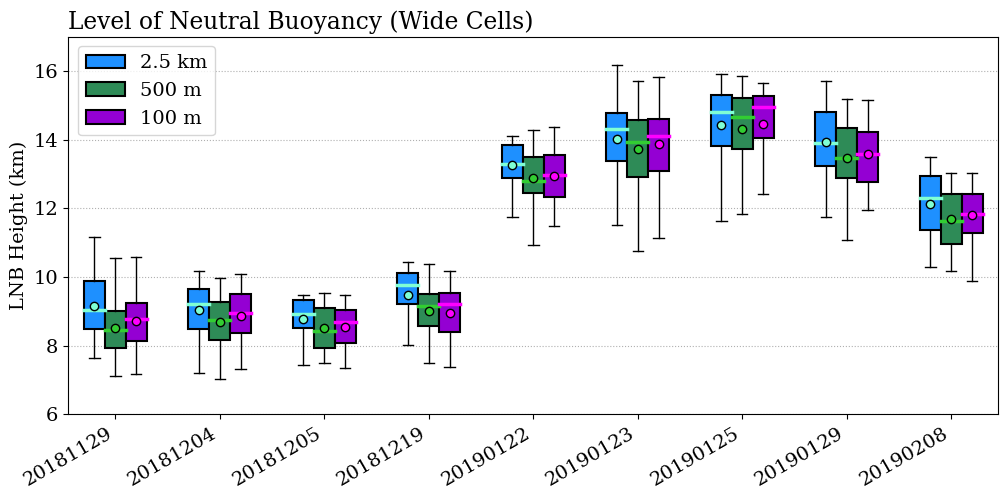

In [55]:
xlabel = start_dates
ylabel = 'LNB Height (km)'
title = 'Level of Neutral Buoyancy (Wide Cells)'
ylim = (6,17)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_pELmu_wide_d2_d3_d4.png'
fig = plot_boxplots(pELmu_date_wide_d2, pELmu_date_wide_d3, pELmu_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

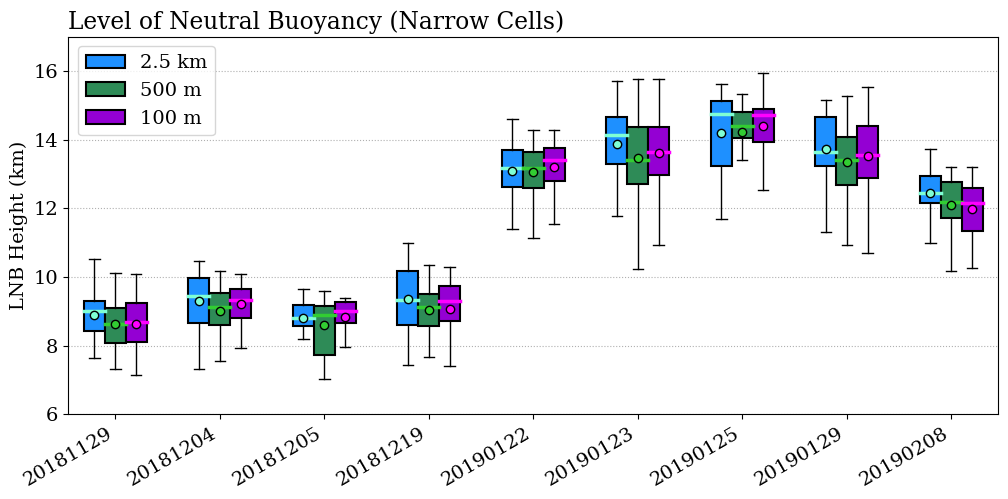

In [56]:
xlabel = start_dates
ylabel = 'LNB Height (km)'
title = 'Level of Neutral Buoyancy (Narrow Cells)'
ylim = (6,17)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_pELmu_narrow_d2_d3_d4.png'
fig = plot_boxplots(pELmu_date_narrow_d2, pELmu_date_narrow_d3, pELmu_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

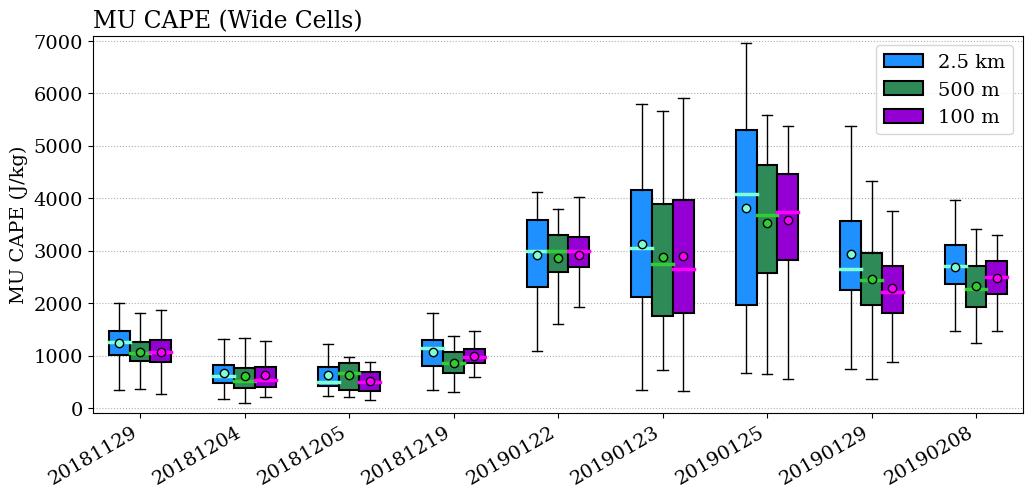

In [57]:
xlabel = start_dates
ylabel = 'MU CAPE (J/kg)'
title = 'MU CAPE (Wide Cells)'
ylim = (-100,7100)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_pCAPEmu_wide_d2_d3_d4.png'
fig = plot_boxplots(pCAPEmu_date_wide_d2, pCAPEmu_date_wide_d3, pCAPEmu_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

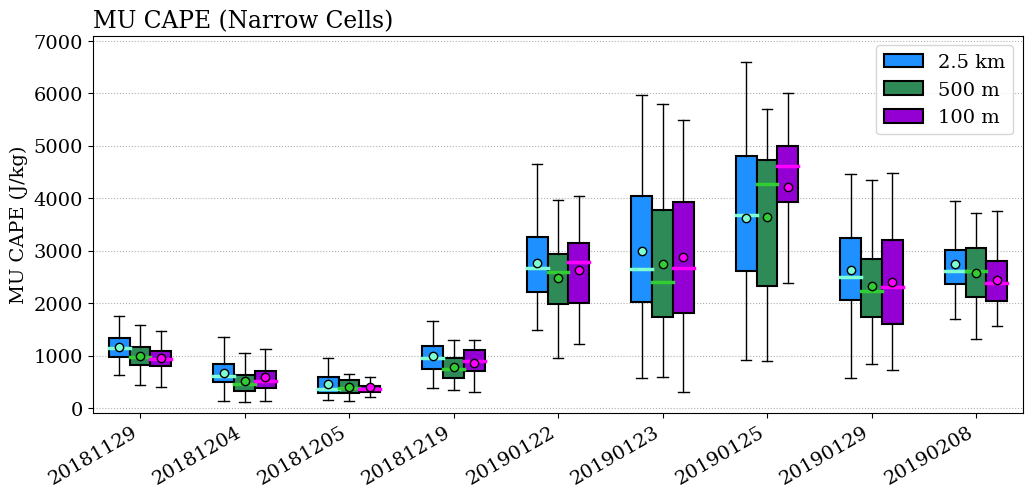

In [58]:
xlabel = start_dates
ylabel = 'MU CAPE (J/kg)'
title = 'MU CAPE (Narrow Cells)'
ylim = (-100,7100)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_pCAPEmu_narrow_d2_d3_d4.png'
fig = plot_boxplots(pCAPEmu_date_narrow_d2, pCAPEmu_date_narrow_d3, pCAPEmu_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

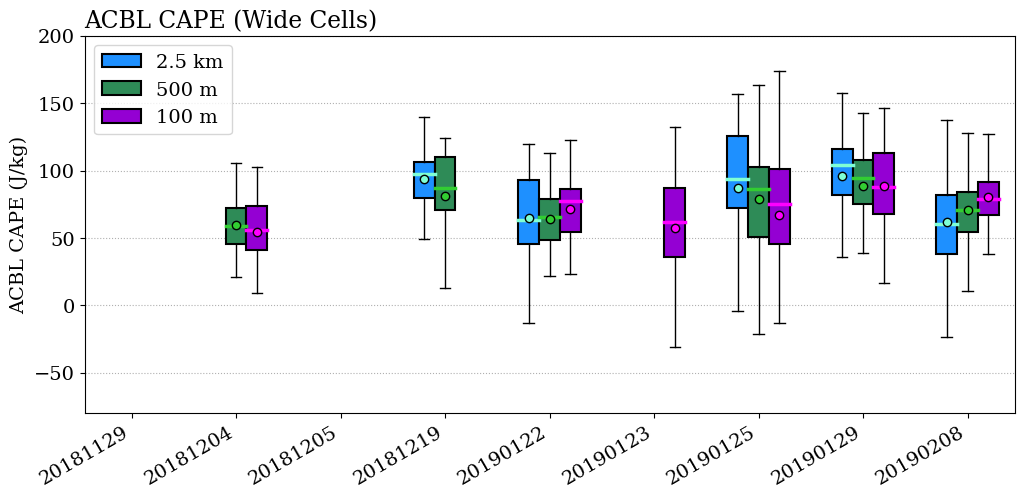

In [59]:
xlabel = start_dates
ylabel = 'ACBL CAPE (J/kg)'
title = 'ACBL CAPE (Wide Cells)'
ylim = (-80,200)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_pCAPEacbl_wide_d2_d3_d4.png'
fig = plot_boxplots(pCAPEacbl_date_wide_d2, pCAPEacbl_date_wide_d3, pCAPEacbl_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

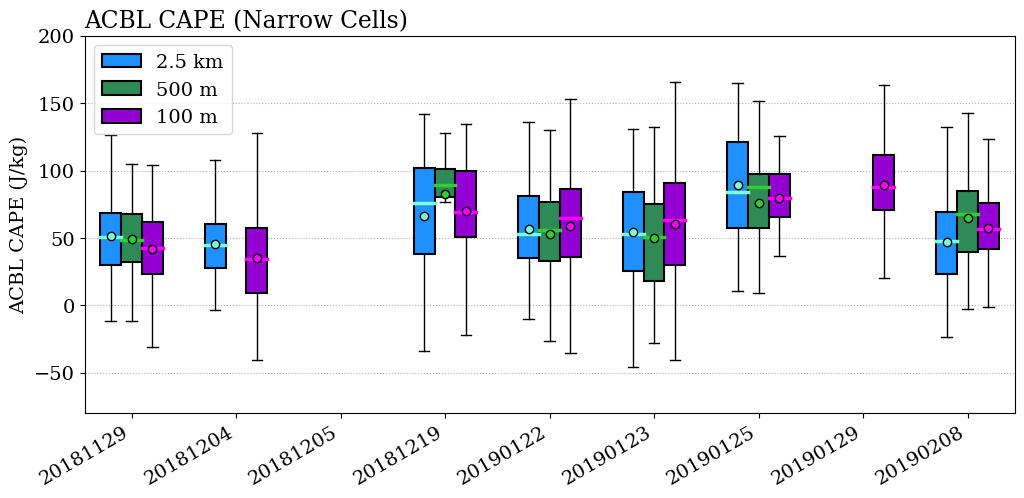

In [60]:
xlabel = start_dates
ylabel = 'ACBL CAPE (J/kg)'
title = 'ACBL CAPE (Narrow Cells)'
ylim = (-80,200)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_pCAPEacbl_narrow_d2_d3_d4.png'
fig = plot_boxplots(pCAPEacbl_date_narrow_d2, pCAPEacbl_date_narrow_d3, pCAPEacbl_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

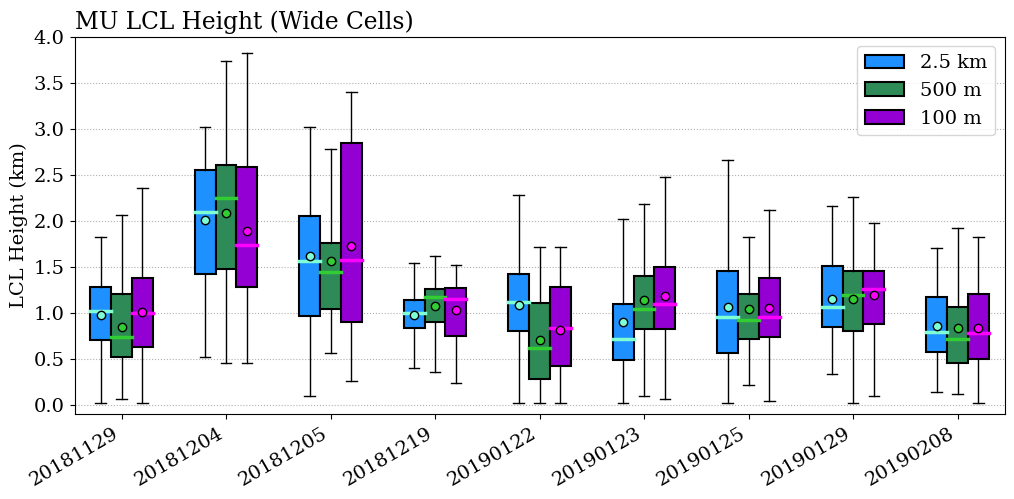

In [61]:
xlabel = start_dates
ylabel = 'LCL Height (km)'
title = 'MU LCL Height (Wide Cells)'
ylim = (-0.1,4)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_pLCLmu_wide_d2_d3_d4.png'
fig = plot_boxplots(pLCLz_date_wide_d2, pLCLz_date_wide_d3, pLCLz_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

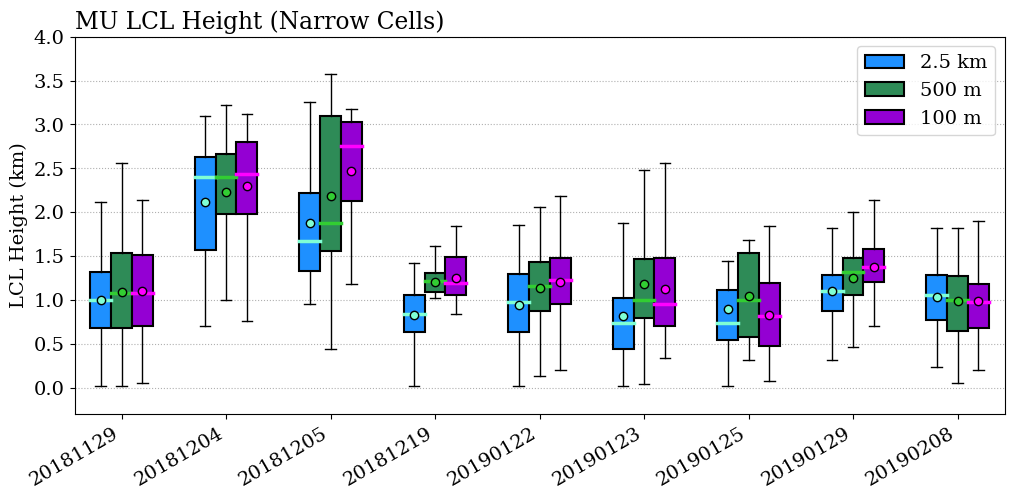

In [62]:
xlabel = start_dates
ylabel = 'LCL Height (km)'
title = 'MU LCL Height (Narrow Cells)'
ylim = (-0.3,4)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_pLCLmu_narrow_d2_d3_d4.png'
fig = plot_boxplots(pLCLz_date_narrow_d2, pLCLz_date_narrow_d3, pLCLz_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

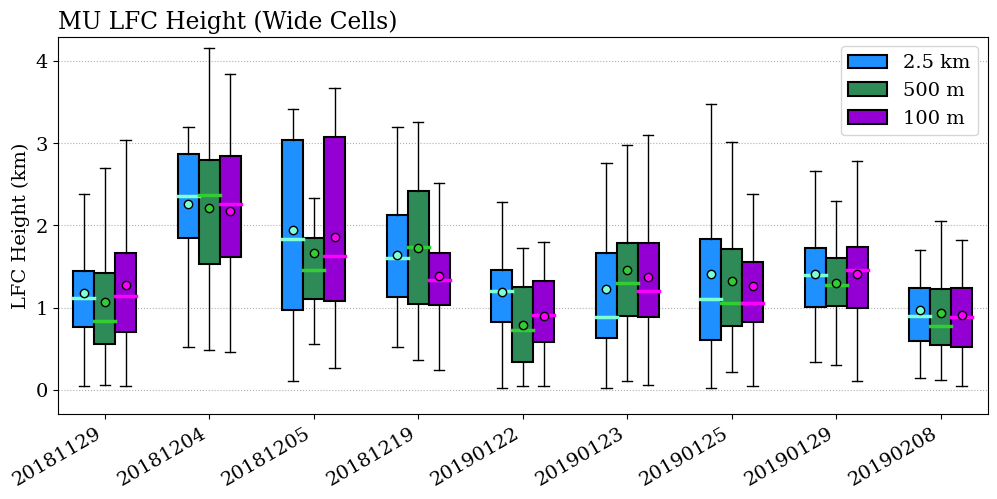

In [63]:
xlabel = start_dates
ylabel = 'LFC Height (km)'
title = 'MU LFC Height (Wide Cells)'
ylim = (-0.3,4.3)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_pLFCmu_wide_d2_d3_d4.png'
fig = plot_boxplots(pLFCz_date_wide_d2, pLFCz_date_wide_d3, pLFCz_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

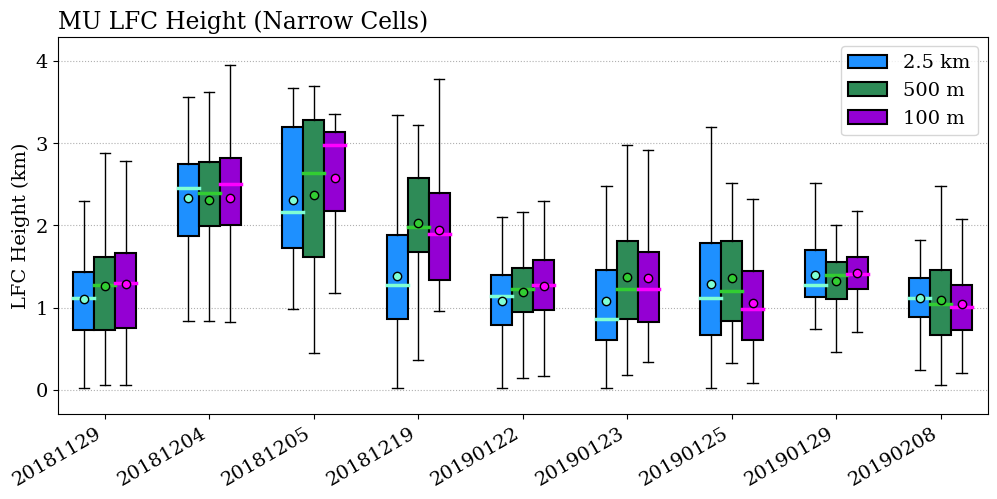

In [64]:
xlabel = start_dates
ylabel = 'LFC Height (km)'
title = 'MU LFC Height (Narrow Cells)'
ylim = (-0.3,4.3)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_pLFCmu_narrow_d2_d3_d4.png'
fig = plot_boxplots(pLFCz_date_narrow_d2, pLFCz_date_narrow_d3, pLFCz_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

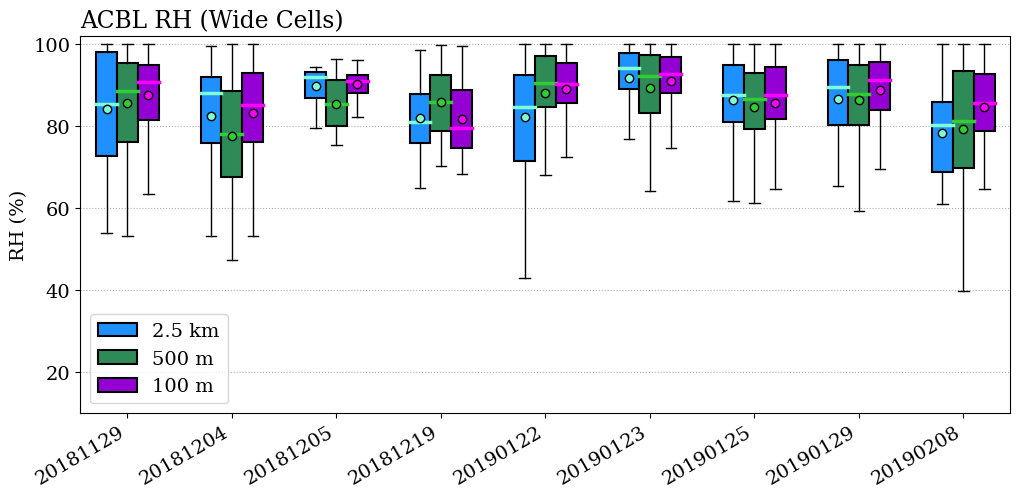

In [65]:
xlabel = start_dates
ylabel = 'RH (%)'
title = 'ACBL RH (Wide Cells)'
ylim = (10,102)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_RHacbl_wide_d2_d3_d4.png'
fig = plot_boxplots(RHacbl_date_wide_d2, RHacbl_date_wide_d3, RHacbl_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

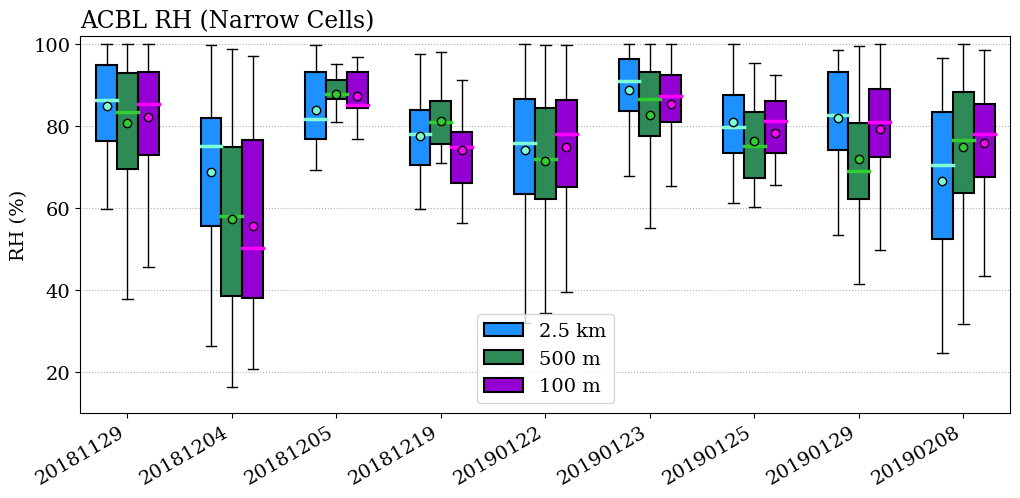

In [66]:
xlabel = start_dates
ylabel = 'RH (%)'
title = 'ACBL RH (Narrow Cells)'
ylim = (10,102)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_RHacbl_narrow_d2_d3_d4.png'
fig = plot_boxplots(RHacbl_date_narrow_d2, RHacbl_date_narrow_d3, RHacbl_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

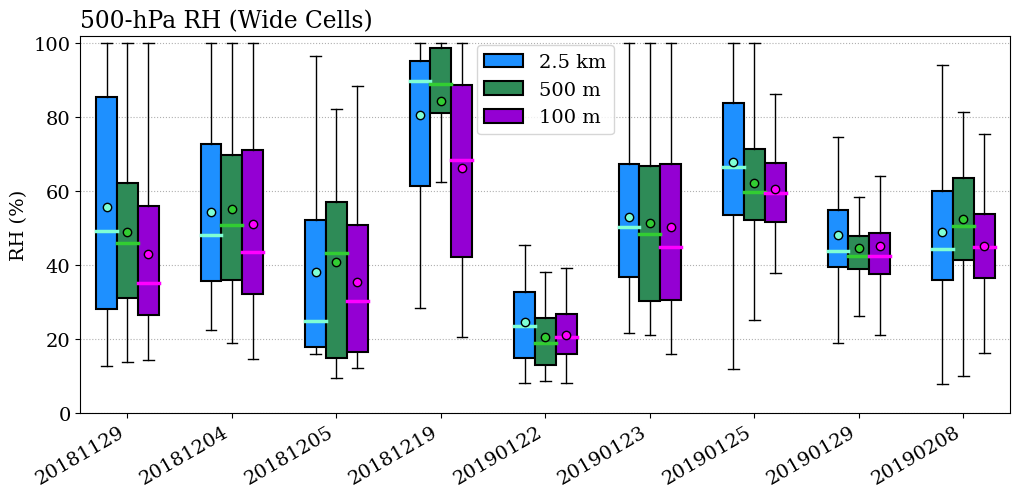

In [67]:
xlabel = start_dates
ylabel = 'RH (%)'
title = '500-hPa RH (Wide Cells)'
ylim = (0,102)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_RH500mb_wide_d2_d3_d4.png'
fig = plot_boxplots(RH500mb_date_wide_d2, RH500mb_date_wide_d3, RH500mb_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

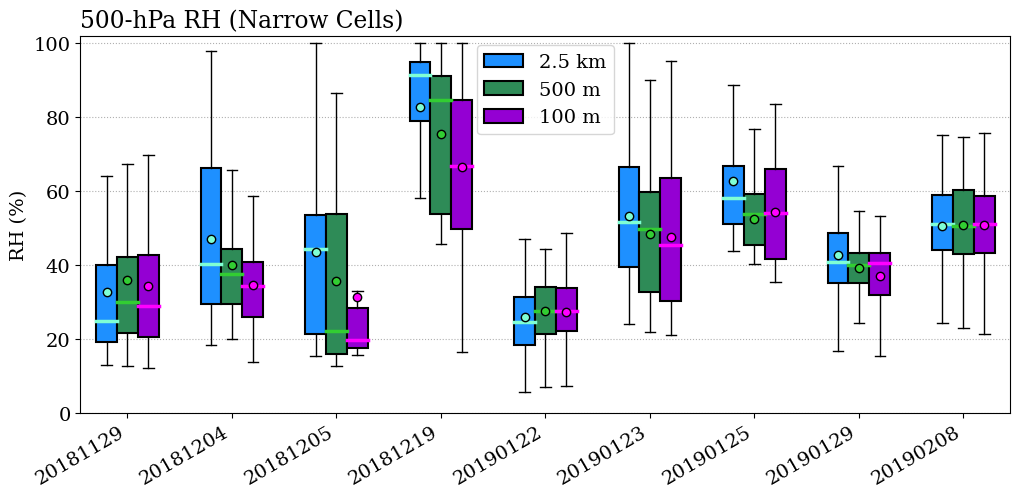

In [68]:
xlabel = start_dates
ylabel = 'RH (%)'
title = '500-hPa RH (Narrow Cells)'
ylim = (0,102)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_RH500mb_narrow_d2_d3_d4.png'
fig = plot_boxplots(RH500mb_date_narrow_d2, RH500mb_date_narrow_d3, RH500mb_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

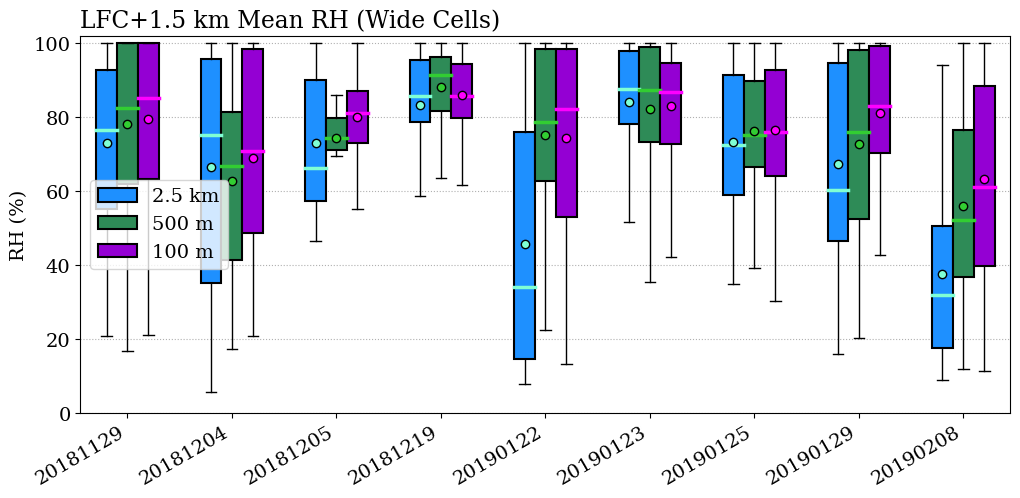

In [69]:
xlabel = start_dates
ylabel = 'RH (%)'
title = 'LFC+1.5 km Mean RH (Wide Cells)'
ylim = (0,102)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_RHlfc1500m_wide_d2_d3_d4.png'
fig = plot_boxplots(RHlfc1500_date_wide_d2, RHlfc1500_date_wide_d3, RHlfc1500_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

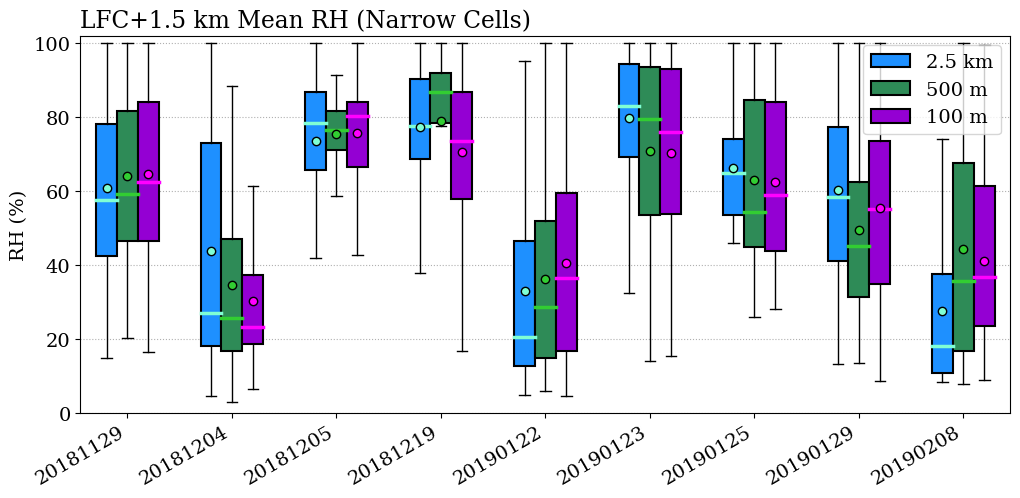

In [70]:
xlabel = start_dates
ylabel = 'RH (%)'
title = 'LFC+1.5 km Mean RH (Narrow Cells)'
ylim = (0,102)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_RHlfc1500m_narrow_d2_d3_d4.png'
fig = plot_boxplots(RHlfc1500_date_narrow_d2, RHlfc1500_date_narrow_d3, RHlfc1500_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

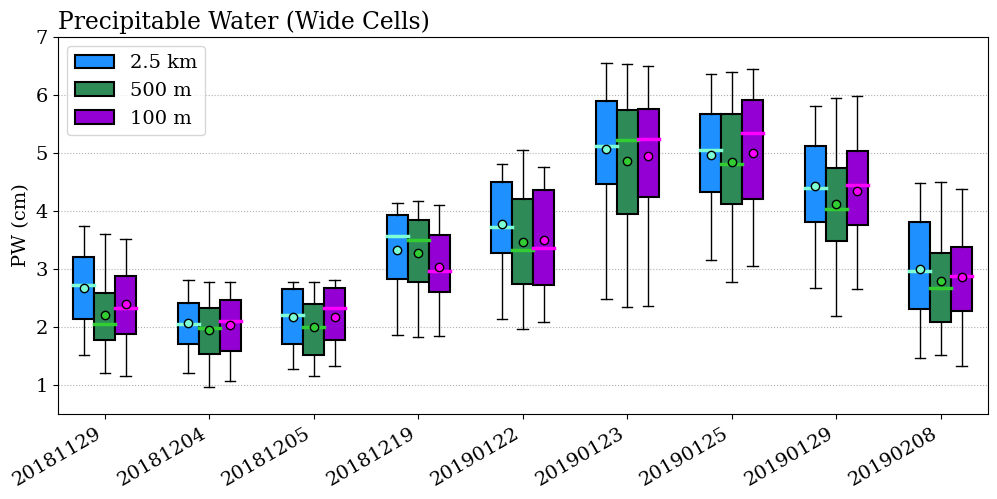

In [71]:
xlabel = start_dates
ylabel = 'PW (cm)'
title = 'Precipitable Water (Wide Cells)'
ylim = (0.5,7)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_PW_wide_d2_d3_d4.png'
fig = plot_boxplots(PW_date_wide_d2, PW_date_wide_d3, PW_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

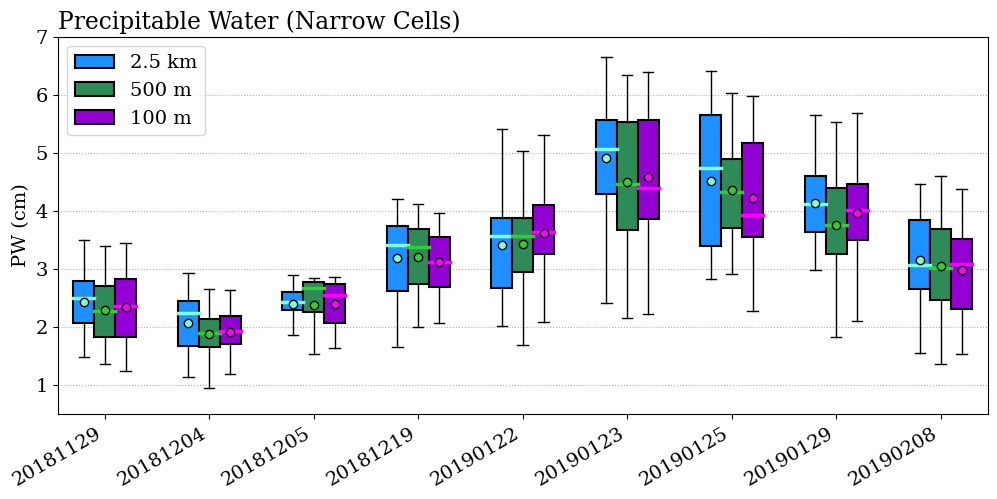

In [72]:
xlabel = start_dates
ylabel = 'PW (cm)'
title = 'Precipitable Water (Narrow Cells)'
ylim = (0.5,7)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_PW_narrow_d2_d3_d4.png'
fig = plot_boxplots(PW_date_narrow_d2, PW_date_narrow_d3, PW_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

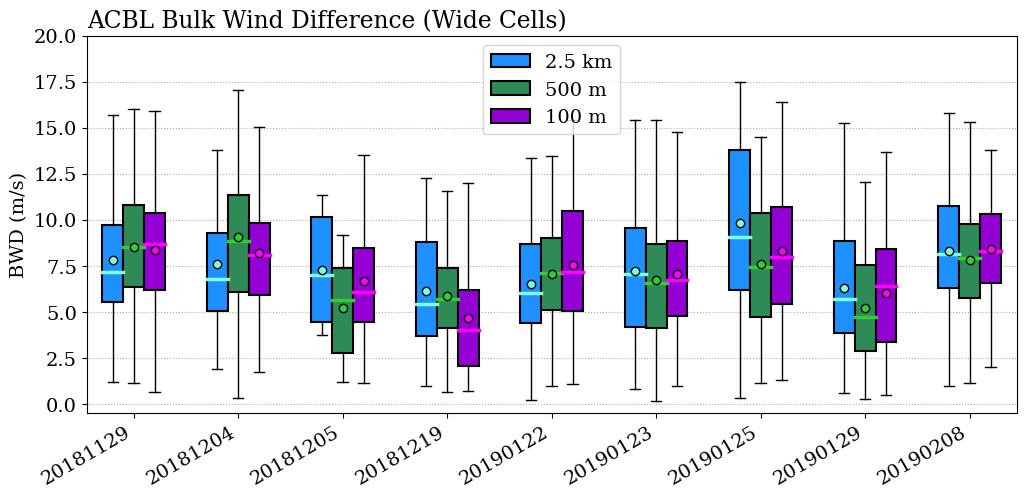

In [73]:
xlabel = start_dates
ylabel = 'BWD (m/s)'
title = 'ACBL Bulk Wind Difference (Wide Cells)'
ylim = (-0.5, 20)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_BWSacbl_wide_d2_d3_d4.png'
fig = plot_boxplots(BWSacbl_date_wide_d2, BWSacbl_date_wide_d3, BWSacbl_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

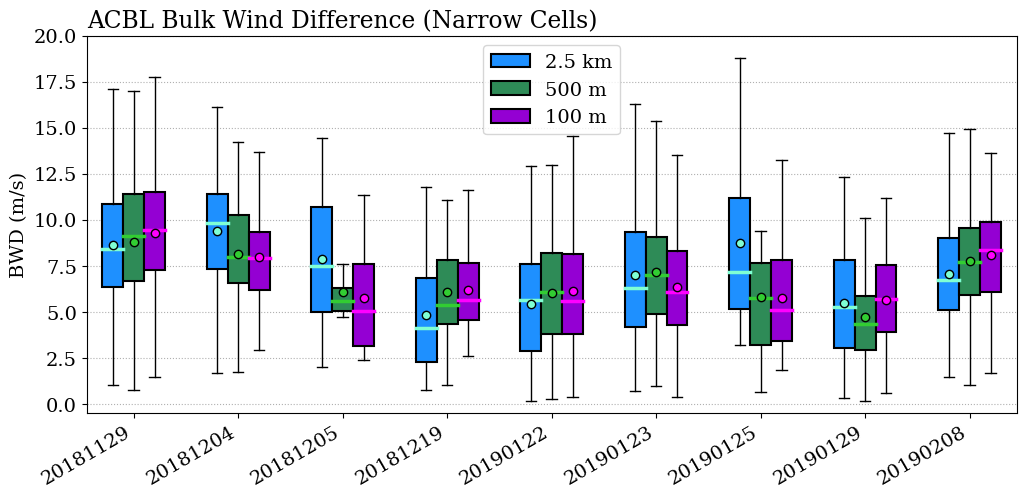

In [74]:
xlabel = start_dates
ylabel = 'BWD (m/s)'
title = 'ACBL Bulk Wind Difference (Narrow Cells)'
ylim = (-0.5, 20)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_BWSacbl_narrow_d2_d3_d4.png'
fig = plot_boxplots(BWSacbl_date_narrow_d2, BWSacbl_date_narrow_d3, BWSacbl_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

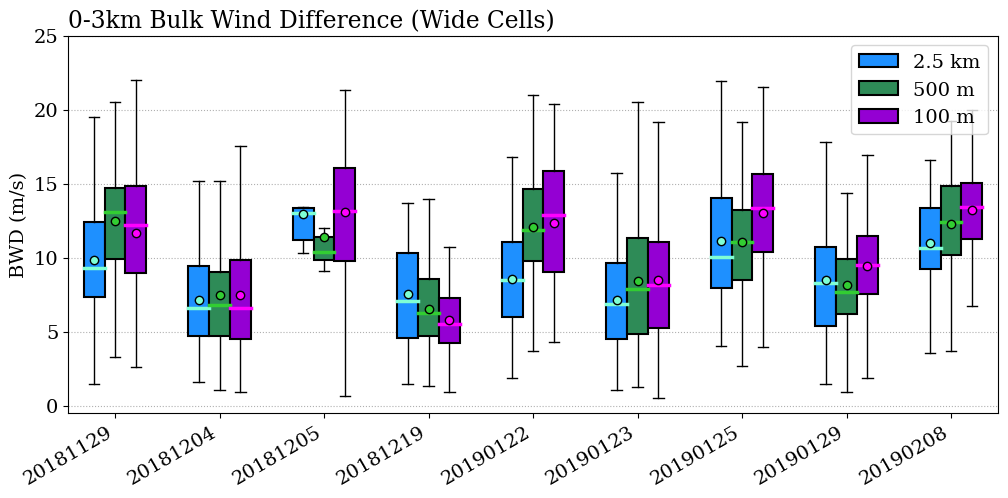

In [75]:
xlabel = start_dates
ylabel = 'BWD (m/s)'
title = '0-3km Bulk Wind Difference (Wide Cells)'
ylim = (-0.5, 25)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_BWS03km_wide_d2_d3_d4.png'
fig = plot_boxplots(BWS03km_date_wide_d2, BWS03km_date_wide_d3, BWS03km_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

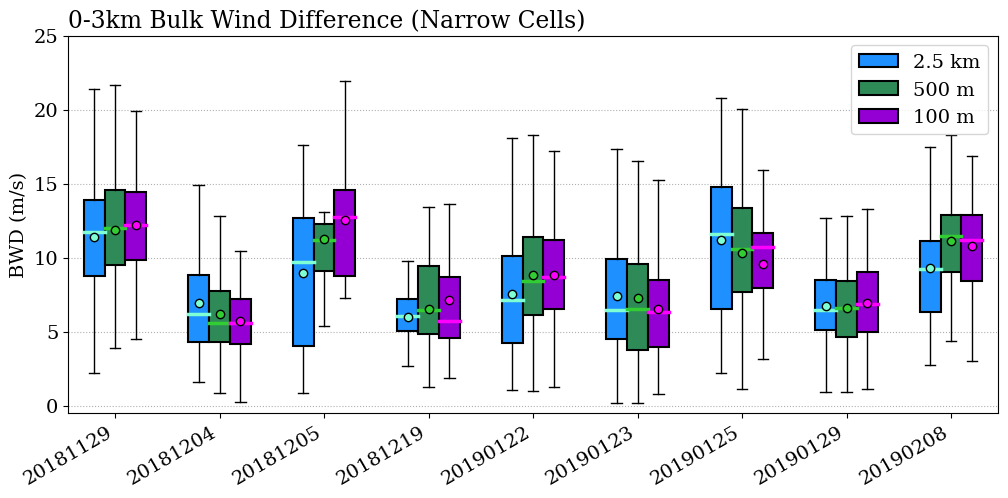

In [76]:
xlabel = start_dates
ylabel = 'BWD (m/s)'
title = '0-3km Bulk Wind Difference (Narrow Cells)'
ylim = (-0.5, 25)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_BWS03km_narrow_d2_d3_d4.png'
fig = plot_boxplots(BWS03km_date_narrow_d2, BWS03km_date_narrow_d3, BWS03km_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

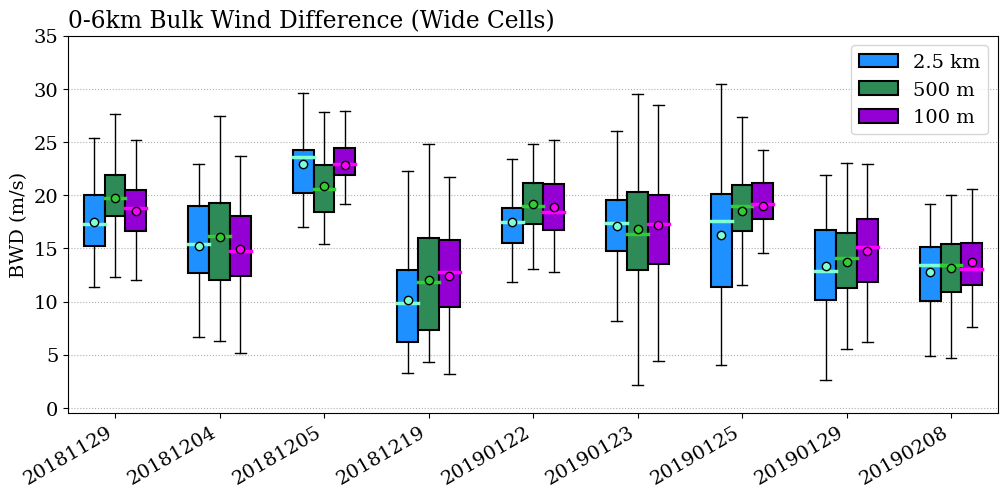

In [77]:
xlabel = start_dates
ylabel = 'BWD (m/s)'
title = '0-6km Bulk Wind Difference (Wide Cells)'
ylim = (-0.5, 35)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_BWS06km_wide_d2_d3_d4.png'
fig = plot_boxplots(BWS06km_date_wide_d2, BWS06km_date_wide_d3, BWS06km_date_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

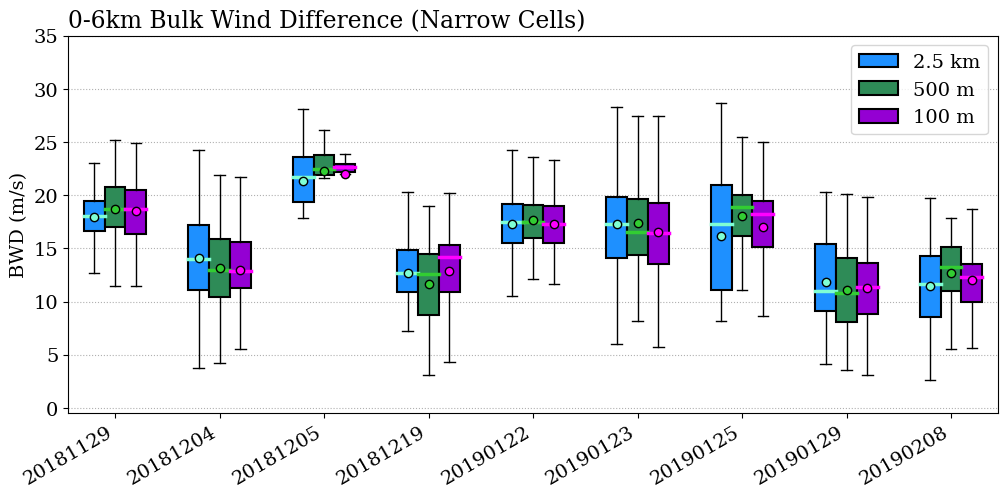

In [78]:
xlabel = start_dates
ylabel = 'BWD (m/s)'
title = '0-6km Bulk Wind Difference (Narrow Cells)'
ylim = (-0.5, 35)
figsize = [12,5]
figname = f'{figdir}BoxplotByDate_BWS06km_narrow_d2_d3_d4.png'
fig = plot_boxplots(BWS06km_date_narrow_d2, BWS06km_date_narrow_d3, BWS06km_date_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)

## Make plots by case

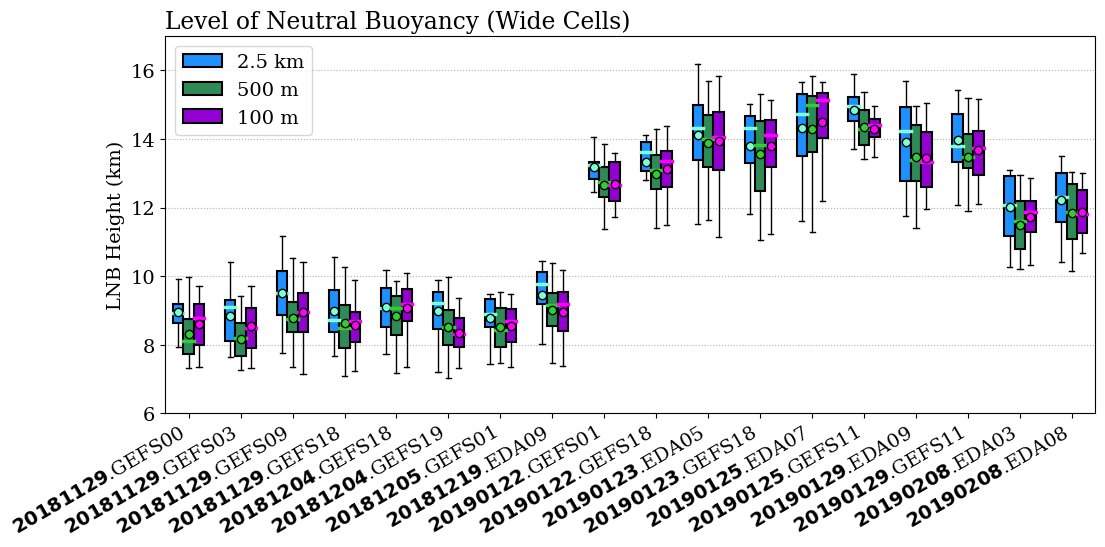

In [79]:
xlabel = uniq_CASES
ylabel = 'LNB Height (km)'
title = 'Level of Neutral Buoyancy (Wide Cells)'
ylim = (6,17)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_pELmu_wide_d2_d3_d4.png'
fig = plot_boxplots(pELmu_case_wide_d2, pELmu_case_wide_d3, pELmu_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

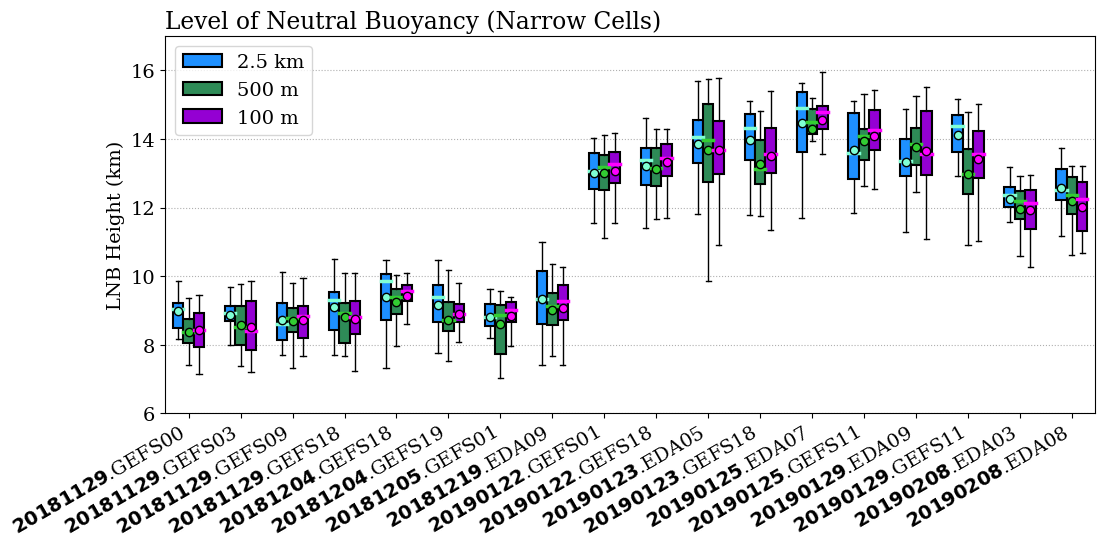

In [80]:
xlabel = uniq_CASES
ylabel = 'LNB Height (km)'
title = 'Level of Neutral Buoyancy (Narrow Cells)'
ylim = (6,17)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_pELmu_narrow_d2_d3_d4.png'
fig = plot_boxplots(pELmu_case_narrow_d2, pELmu_case_narrow_d3, pELmu_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

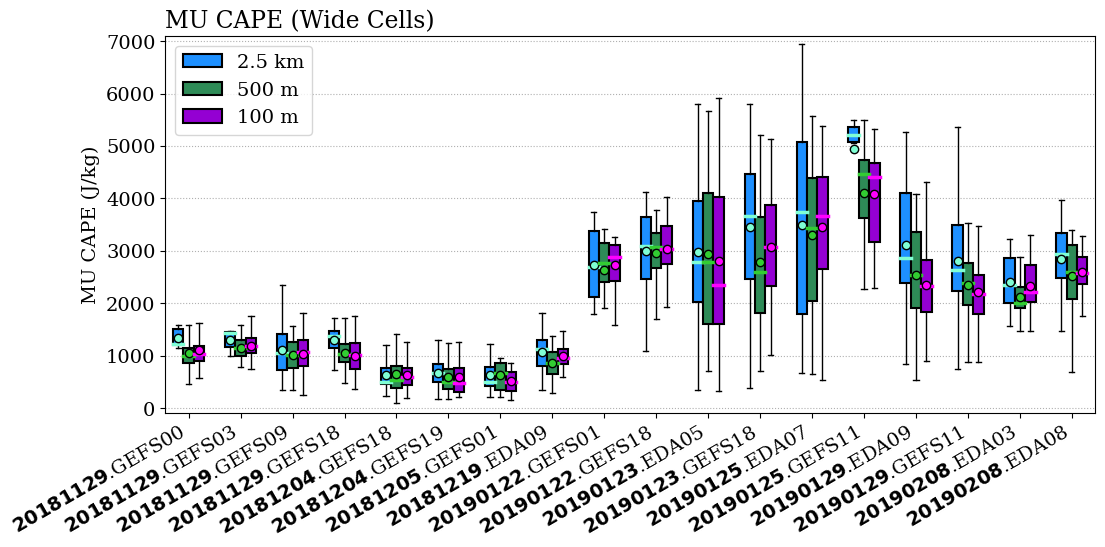

In [81]:
xlabel = uniq_CASES
ylabel = 'MU CAPE (J/kg)'
title = 'MU CAPE (Wide Cells)'
ylim = (-100,7100)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_pCAPEmu_wide_d2_d3_d4.png'
fig = plot_boxplots(pCAPEmu_case_wide_d2, pCAPEmu_case_wide_d3, pCAPEmu_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

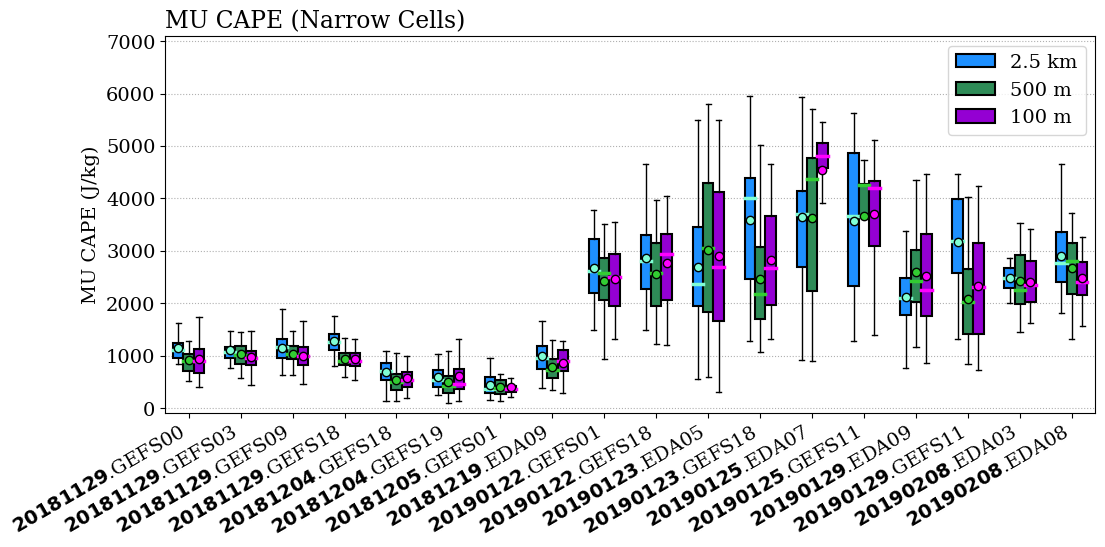

In [82]:
xlabel = uniq_CASES
ylabel = 'MU CAPE (J/kg)'
title = 'MU CAPE (Narrow Cells)'
ylim = (-100,7100)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_pCAPEmu_narrow_d2_d3_d4.png'
fig = plot_boxplots(pCAPEmu_case_narrow_d2, pCAPEmu_case_narrow_d3, pCAPEmu_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

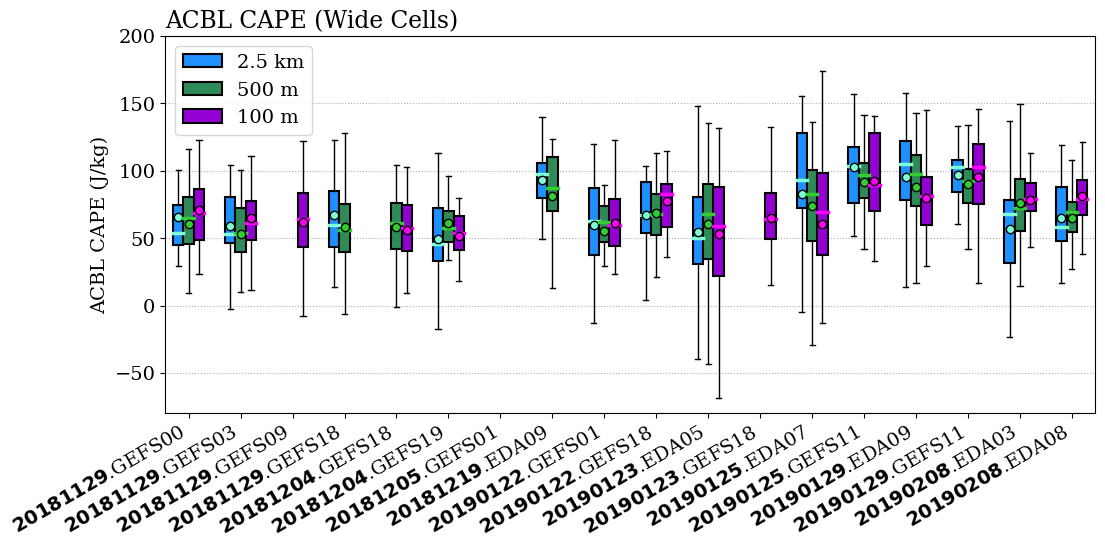

In [83]:
xlabel = uniq_CASES
ylabel = 'ACBL CAPE (J/kg)'
title = 'ACBL CAPE (Wide Cells)'
ylim = (-80,200)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_pCAPEacbl_wide_d2_d3_d4.png'
fig = plot_boxplots(pCAPEacbl_case_wide_d2, pCAPEacbl_case_wide_d3, pCAPEacbl_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

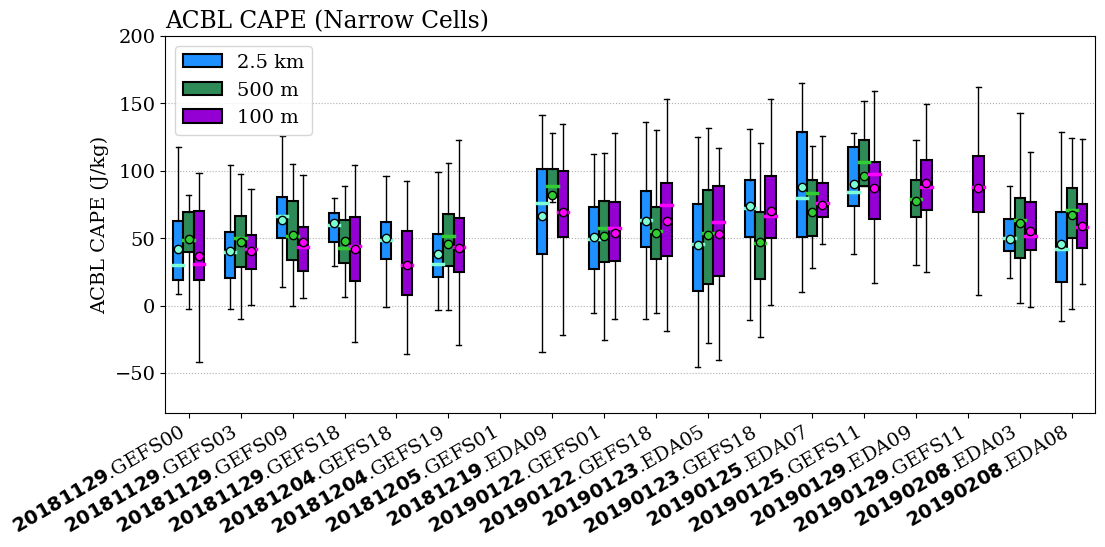

In [84]:
xlabel = uniq_CASES
ylabel = 'ACBL CAPE (J/kg)'
title = 'ACBL CAPE (Narrow Cells)'
ylim = (-80,200)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_pCAPEacbl_narrow_d2_d3_d4.png'
fig = plot_boxplots(pCAPEacbl_case_narrow_d2, pCAPEacbl_case_narrow_d3, pCAPEacbl_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

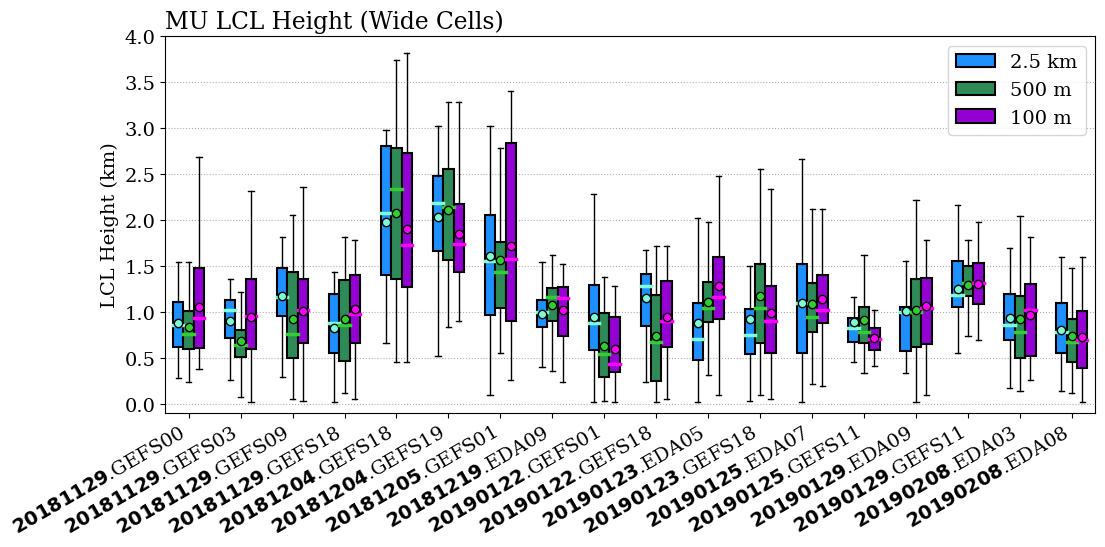

In [85]:
xlabel = uniq_CASES
ylabel = 'LCL Height (km)'
title = 'MU LCL Height (Wide Cells)'
ylim = (-0.1,4)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_pLCLmu_wide_d2_d3_d4.png'
fig = plot_boxplots(pLCLz_case_wide_d2, pLCLz_case_wide_d3, pLCLz_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

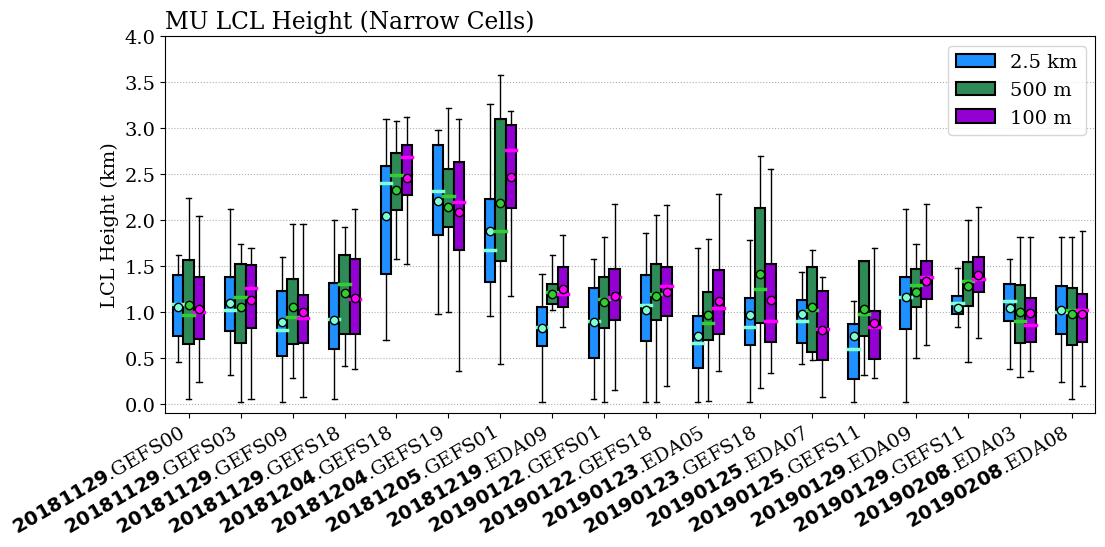

In [86]:
xlabel = uniq_CASES
ylabel = 'LCL Height (km)'
title = 'MU LCL Height (Narrow Cells)'
ylim = (-0.1,4)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_pLCLmu_narrow_d2_d3_d4.png'
fig = plot_boxplots(pLCLz_case_narrow_d2, pLCLz_case_narrow_d3, pLCLz_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

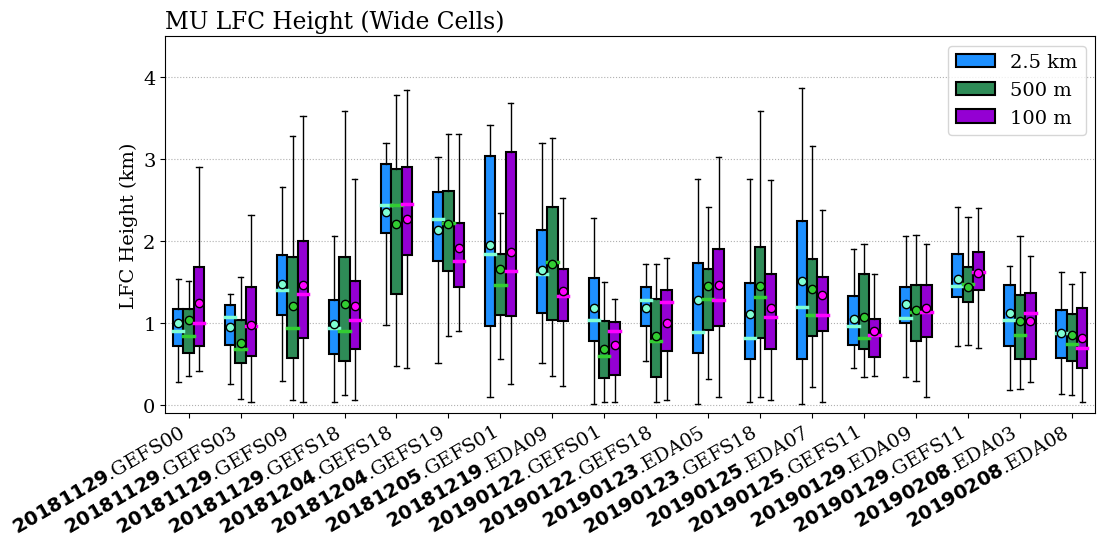

In [87]:
xlabel = uniq_CASES
ylabel = 'LFC Height (km)'
title = 'MU LFC Height (Wide Cells)'
ylim = (-0.1,4.5)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_pLFCmu_wide_d2_d3_d4.png'
fig = plot_boxplots(pLFCz_case_wide_d2, pLFCz_case_wide_d3, pLFCz_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

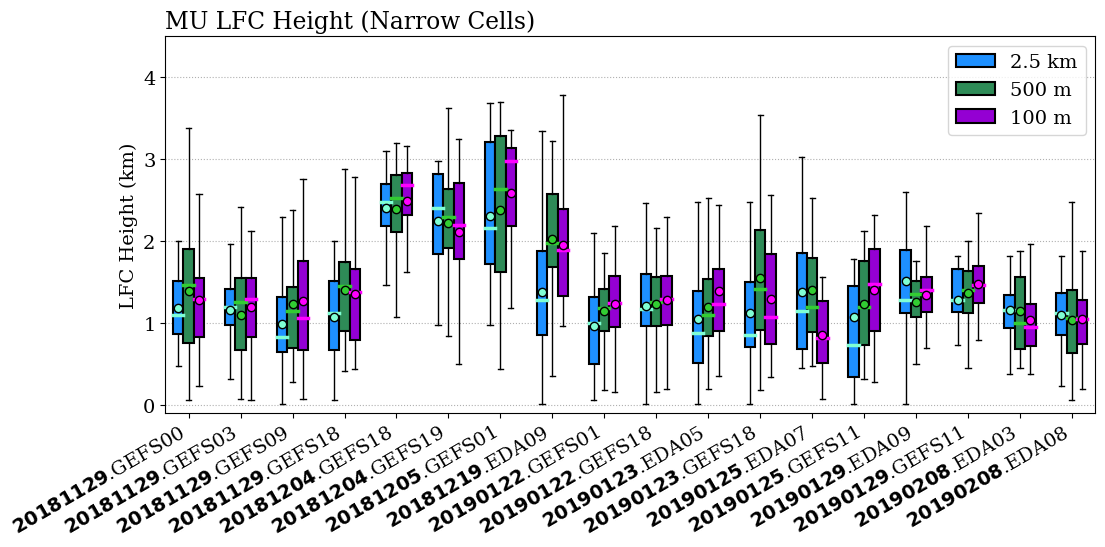

In [88]:
xlabel = uniq_CASES
ylabel = 'LFC Height (km)'
title = 'MU LFC Height (Narrow Cells)'
ylim = (-0.1,4.5)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_pLFCmu_narrow_d2_d3_d4.png'
fig = plot_boxplots(pLFCz_case_narrow_d2, pLFCz_case_narrow_d3, pLFCz_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

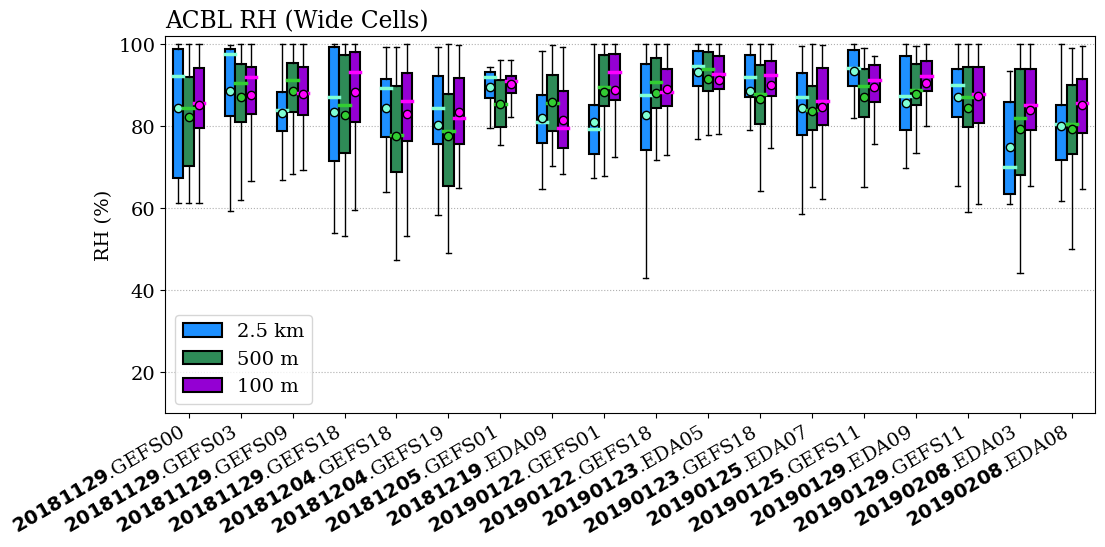

In [89]:
xlabel = uniq_CASES
ylabel = 'RH (%)'
title = 'ACBL RH (Wide Cells)'
ylim = (10,102)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_RHacbl_wide_d2_d3_d4.png'
fig = plot_boxplots(RHacbl_case_wide_d2, RHacbl_case_wide_d3, RHacbl_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

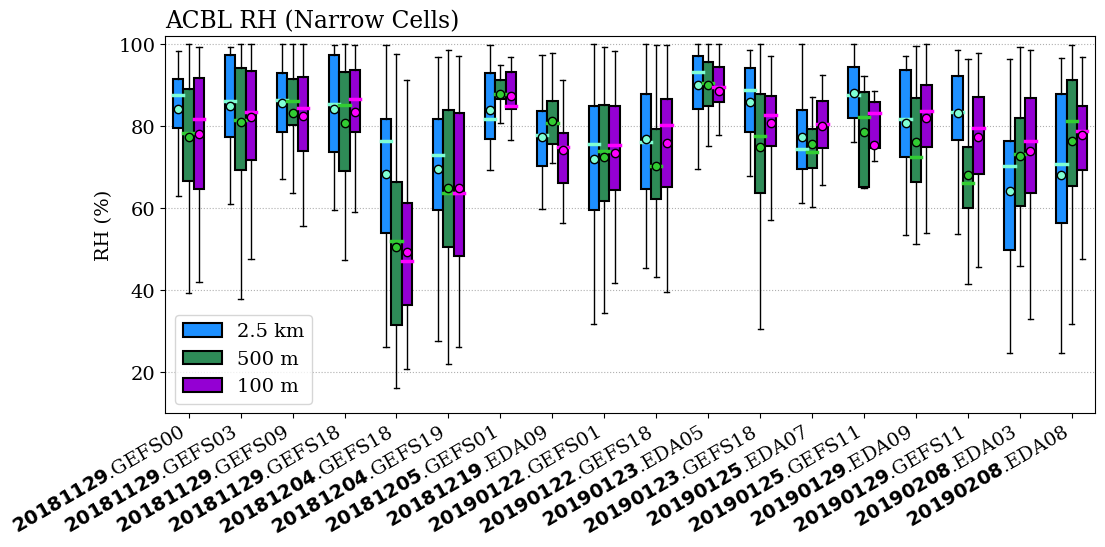

In [90]:
xlabel = uniq_CASES
ylabel = 'RH (%)'
title = 'ACBL RH (Narrow Cells)'
ylim = (10,102)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_RHacbl_narrow_d2_d3_d4.png'
fig = plot_boxplots(RHacbl_case_narrow_d2, RHacbl_case_narrow_d3, RHacbl_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

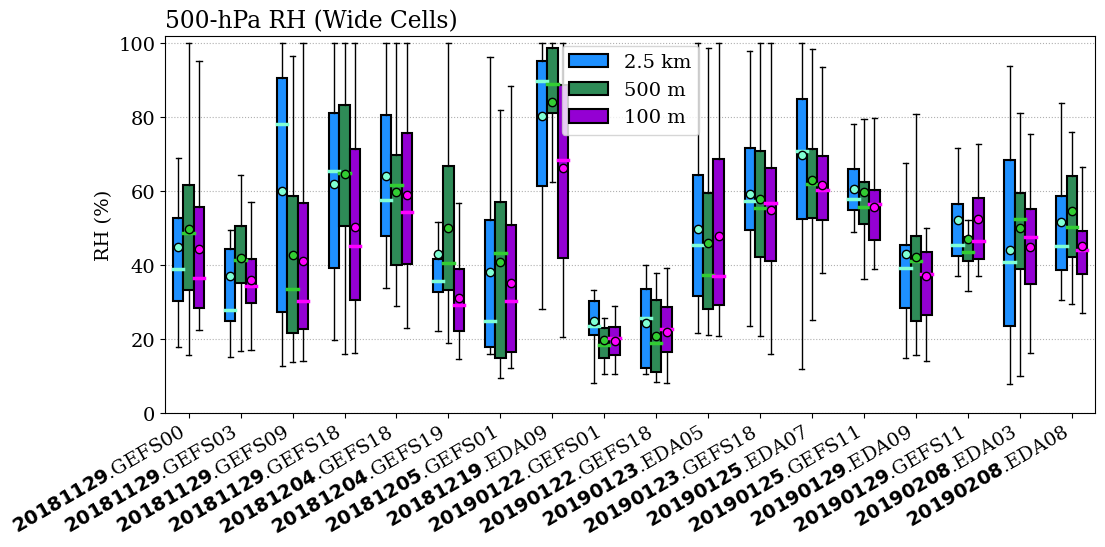

In [91]:
xlabel = uniq_CASES
ylabel = 'RH (%)'
title = '500-hPa RH (Wide Cells)'
ylim = (0,102)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_RH500mb_wide_d2_d3_d4.png'
fig = plot_boxplots(RH500mb_case_wide_d2, RH500mb_case_wide_d3, RH500mb_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

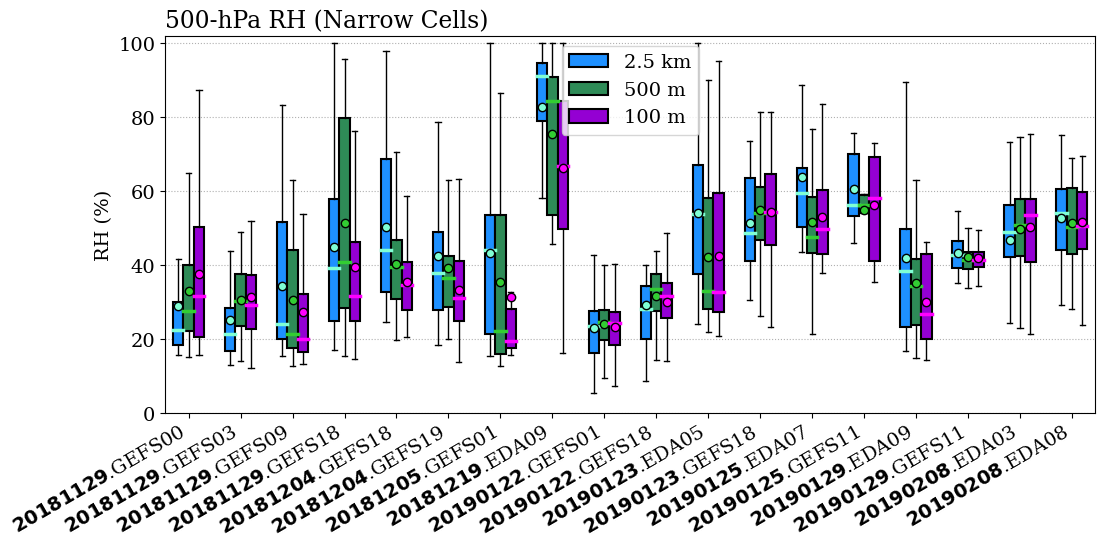

In [92]:
xlabel = uniq_CASES
ylabel = 'RH (%)'
title = '500-hPa RH (Narrow Cells)'
ylim = (0,102)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_RH500mb_narrow_d2_d3_d4.png'
fig = plot_boxplots(RH500mb_case_narrow_d2, RH500mb_case_narrow_d3, RH500mb_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

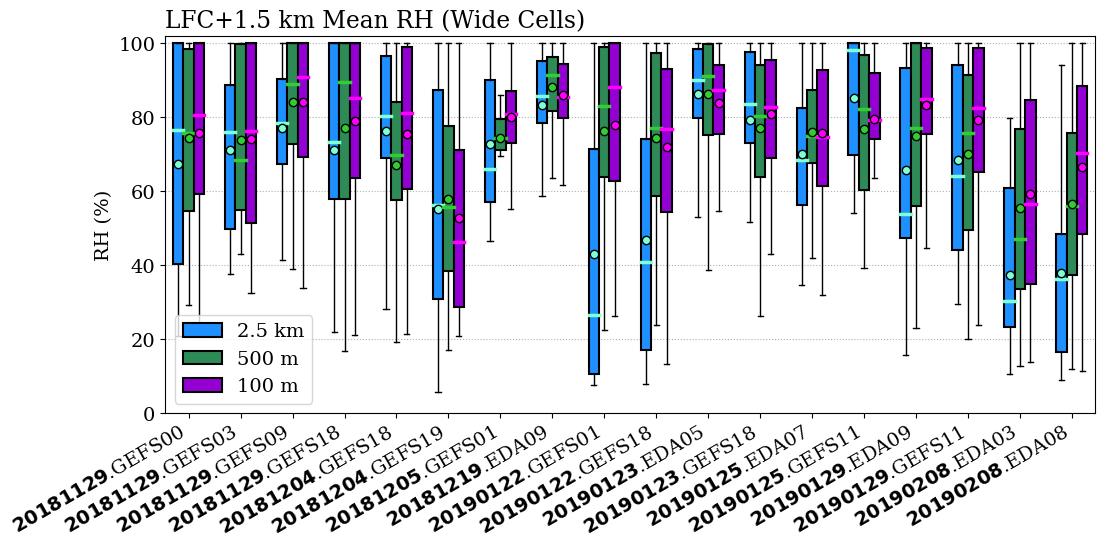

In [93]:
xlabel = uniq_CASES
ylabel = 'RH (%)'
title = 'LFC+1.5 km Mean RH (Wide Cells)'
ylim = (0,102)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_RHlfc1500m_wide_d2_d3_d4.png'
fig = plot_boxplots(RHlfc1500_case_wide_d2, RHlfc1500_case_wide_d3, RHlfc1500_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

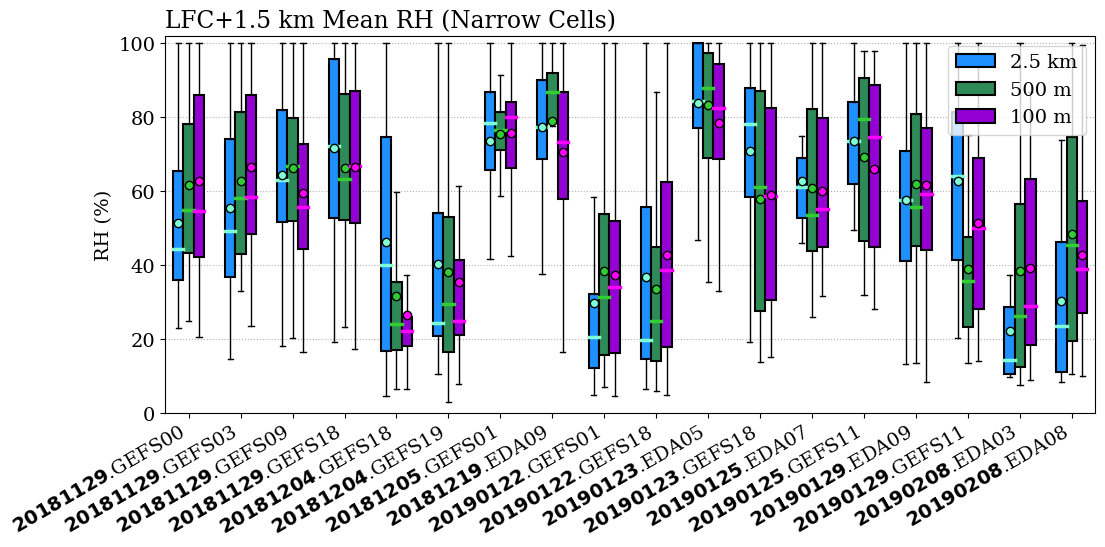

In [94]:
xlabel = uniq_CASES
ylabel = 'RH (%)'
title = 'LFC+1.5 km Mean RH (Narrow Cells)'
ylim = (0,102)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_RHlfc1500m_narrow_d2_d3_d4.png'
fig = plot_boxplots(RHlfc1500_case_narrow_d2, RHlfc1500_case_narrow_d3, RHlfc1500_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

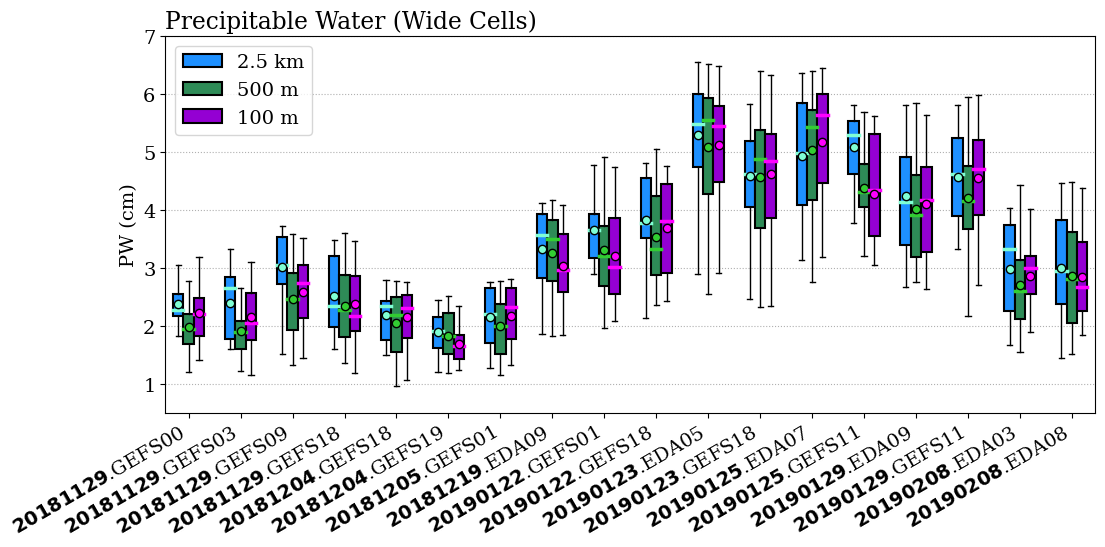

In [95]:
xlabel = uniq_CASES
ylabel = 'PW (cm)'
title = 'Precipitable Water (Wide Cells)'
ylim = (0.5,7)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_PW_wide_d2_d3_d4.png'
fig = plot_boxplots(PW_case_wide_d2, PW_case_wide_d3, PW_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

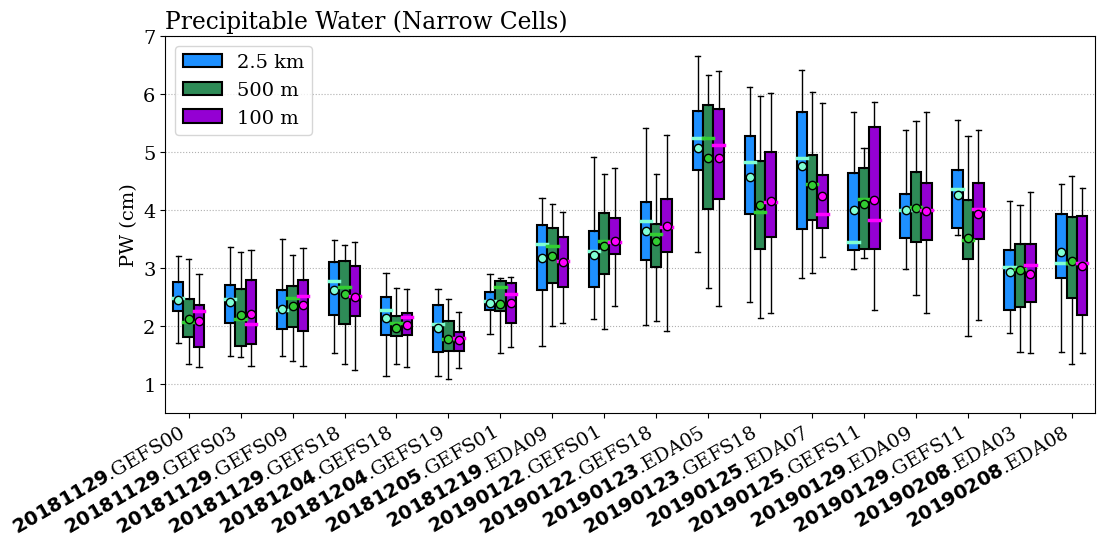

In [96]:
xlabel = uniq_CASES
ylabel = 'PW (cm)'
title = 'Precipitable Water (Narrow Cells)'
ylim = (0.5,7)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_PW_narrow_d2_d3_d4.png'
fig = plot_boxplots(PW_case_narrow_d2, PW_case_narrow_d3, PW_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

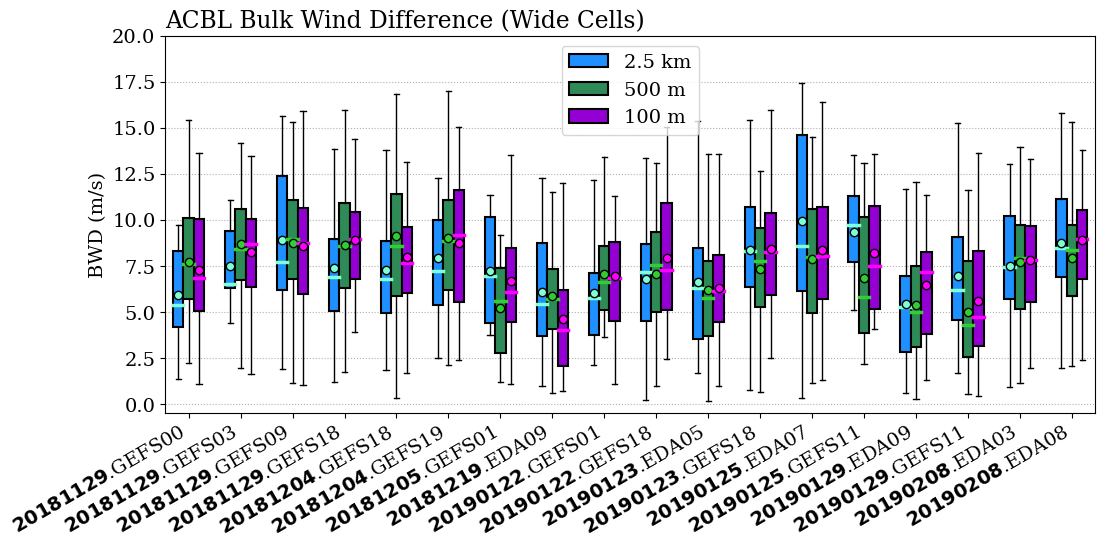

In [97]:
xlabel = uniq_CASES
ylabel = 'BWD (m/s)'
title = 'ACBL Bulk Wind Difference (Wide Cells)'
ylim = (-0.5,20)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_BWSacbl_wide_d2_d3_d4.png'
fig = plot_boxplots(BWSacbl_case_wide_d2, BWSacbl_case_wide_d3, BWSacbl_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

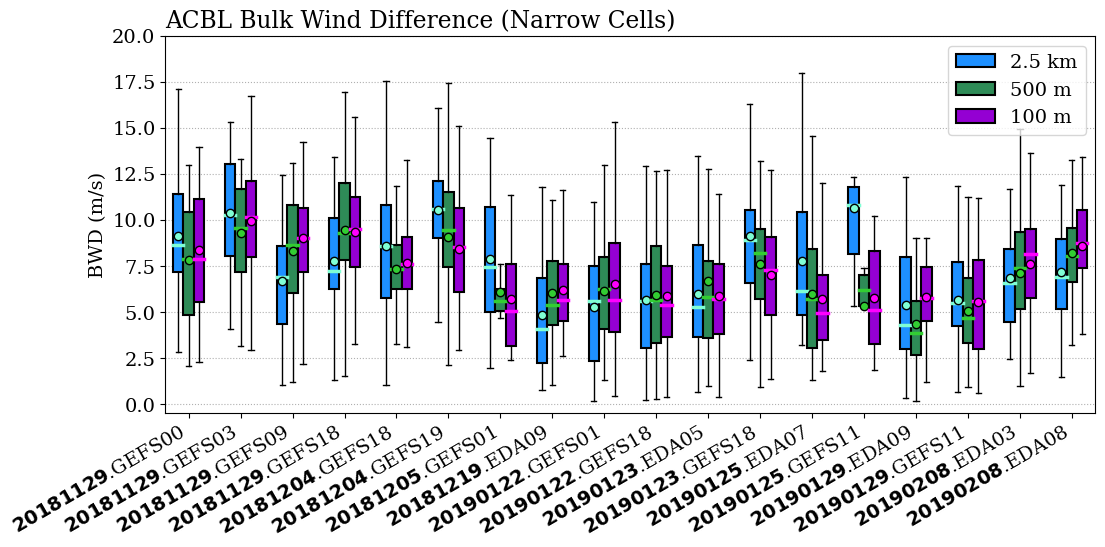

In [98]:
xlabel = uniq_CASES
ylabel = 'BWD (m/s)'
title = 'ACBL Bulk Wind Difference (Narrow Cells)'
ylim = (-0.5,20)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_BWSacbl_narrow_d2_d3_d4.png'
fig = plot_boxplots(BWSacbl_case_narrow_d2, BWSacbl_case_narrow_d3, BWSacbl_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

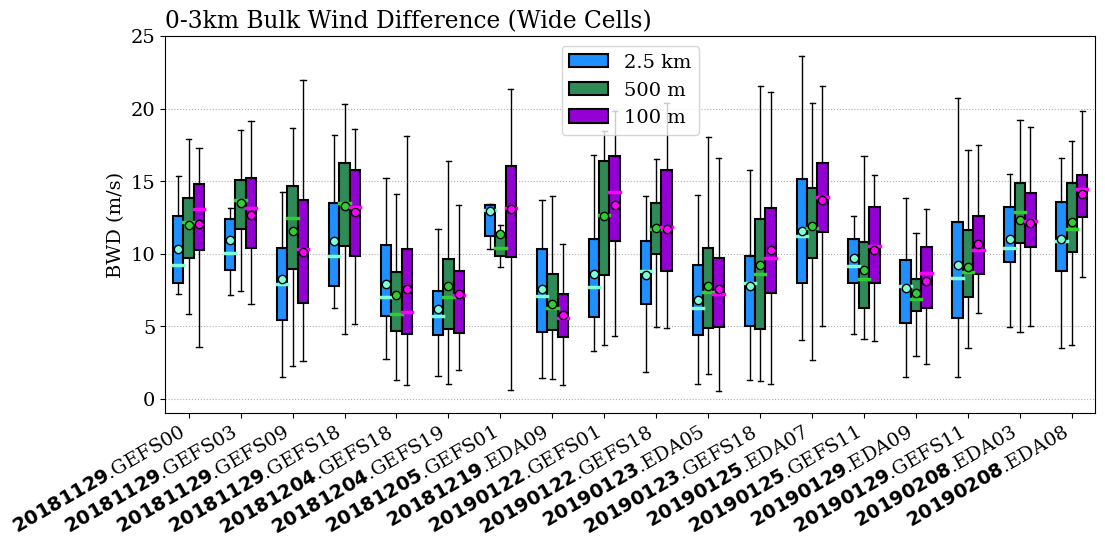

In [99]:
xlabel = uniq_CASES
ylabel = 'BWD (m/s)'
title = '0-3km Bulk Wind Difference (Wide Cells)'
ylim = (-1,25)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_BWS03km_wide_d2_d3_d4.png'
fig = plot_boxplots(BWS03km_case_wide_d2, BWS03km_case_wide_d3, BWS03km_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

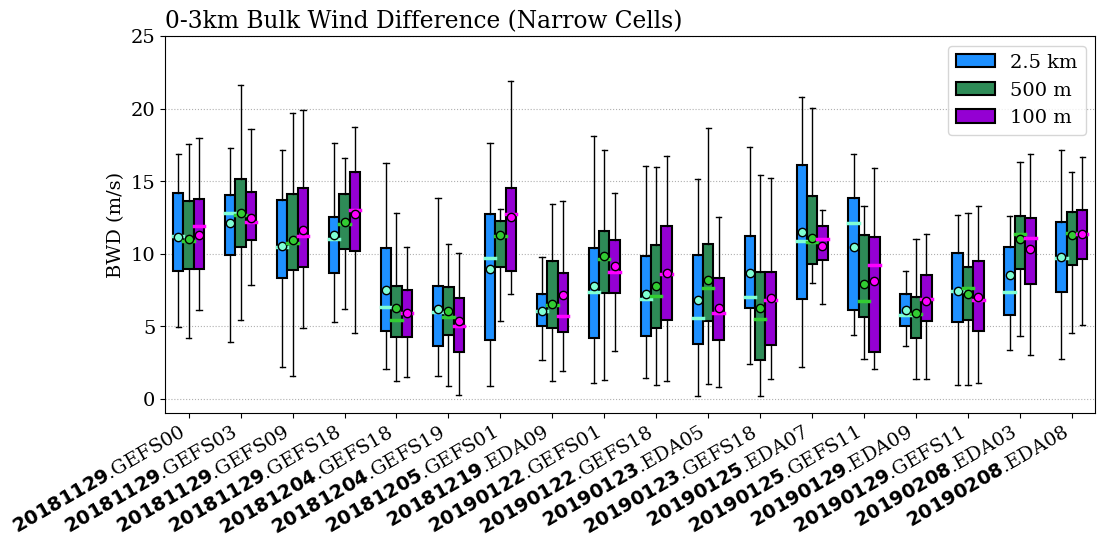

In [100]:
xlabel = uniq_CASES
ylabel = 'BWD (m/s)'
title = '0-3km Bulk Wind Difference (Narrow Cells)'
ylim = (-1,25)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_BWS03km_narrow_d2_d3_d4.png'
fig = plot_boxplots(BWS03km_case_narrow_d2, BWS03km_case_narrow_d3, BWS03km_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

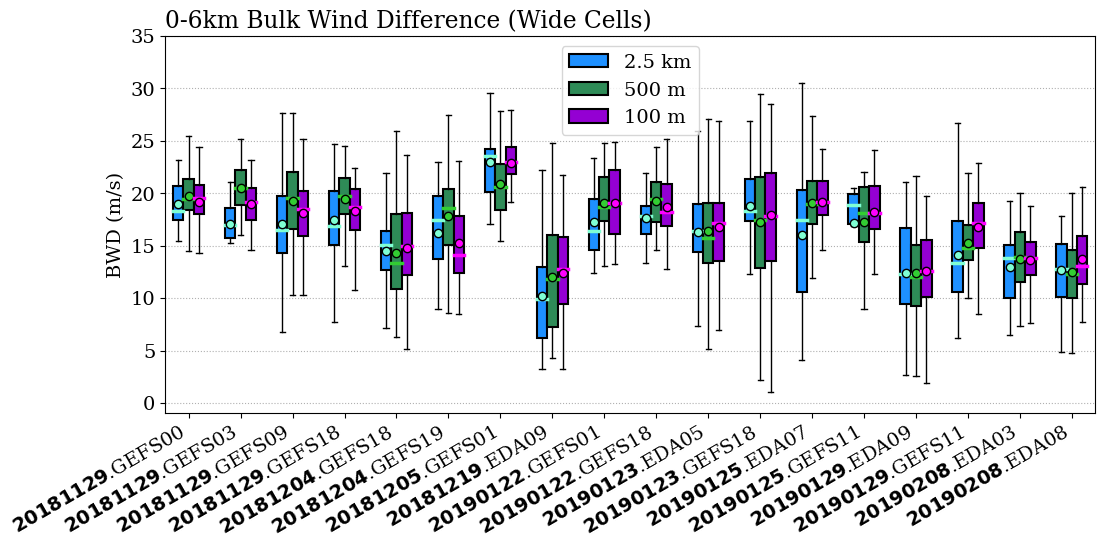

In [101]:
xlabel = uniq_CASES
ylabel = 'BWD (m/s)'
title = '0-6km Bulk Wind Difference (Wide Cells)'
ylim = (-1,35)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_BWS06km_wide_d2_d3_d4.png'
fig = plot_boxplots(BWS06km_case_wide_d2, BWS06km_case_wide_d3, BWS06km_case_wide_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

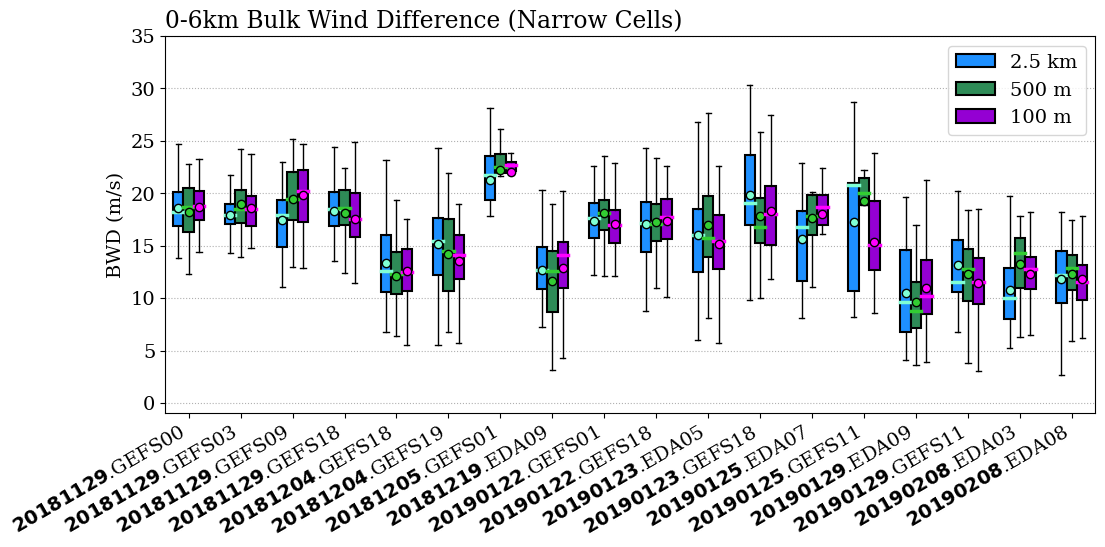

In [102]:
xlabel = uniq_CASES
ylabel = 'BWD (m/s)'
title = '0-6km Bulk Wind Difference (Narrow Cells)'
ylim = (-1,35)
figsize = [12,5]
figname = f'{figdir}BoxplotByCase_BWS06km_narrow_d2_d3_d4.png'
fig = plot_boxplots(BWS06km_case_narrow_d2, BWS06km_case_narrow_d3, BWS06km_case_narrow_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname, bold_xlabel=True)

In [103]:
# pELmu_case_wide_d2 = get_var_by_case(ds_wide_d2, 'pEL_height_mu', preCI_t, scale=1e-3)
# pELmu_case_wide_d3 = get_var_by_case(ds_wide_d3, 'pEL_height_mu', preCI_t, scale=1e-3)
# pELmu_case_wide_d4 = get_var_by_case(ds_wide_d4, 'pEL_height_mu', preCI_t, scale=1e-3)

# pCAPEmu_case_wide_d2 = get_var_by_case(ds_wide_d2, 'pCAPE_mu', preCI_t)
# pCAPEmu_case_wide_d3 = get_var_by_case(ds_wide_d3, 'pCAPE_mu', preCI_t)
# pCAPEmu_case_wide_d4 = get_var_by_case(ds_wide_d4, 'pCAPE_mu', preCI_t)

# pCAPEacbl_case_wide_d2 = get_var_by_case(ds_wide_d2, 'pCAPEacbl_ml', preCI_t)
# pCAPEacbl_case_wide_d3 = get_var_by_case(ds_wide_d3, 'pCAPEacbl_ml', preCI_t)
# pCAPEacbl_case_wide_d4 = get_var_by_case(ds_wide_d4, 'pCAPEacbl_ml', preCI_t)

# pLCLz_case_wide_d2 = get_var_by_case(ds_wide_d2, 'LCL_height_mu', preCI_t, scale=1e-3)
# pLCLz_case_wide_d3 = get_var_by_case(ds_wide_d3, 'LCL_height_mu', preCI_t, scale=1e-3)
# pLCLz_case_wide_d4 = get_var_by_case(ds_wide_d4, 'LCL_height_mu', preCI_t, scale=1e-3)

# pLFCz_case_wide_d2 = get_var_by_case(ds_wide_d2, 'LFC_height_mu', preCI_t, scale=1e-3)
# pLFCz_case_wide_d3 = get_var_by_case(ds_wide_d3, 'LFC_height_mu', preCI_t, scale=1e-3)
# pLFCz_case_wide_d4 = get_var_by_case(ds_wide_d4, 'LFC_height_mu', preCI_t, scale=1e-3)

# RHacbl_case_wide_d2 = get_var_by_case(ds_wide_d2, 'RH_mean_ACBL', preCI_t)
# RHacbl_case_wide_d3 = get_var_by_case(ds_wide_d3, 'RH_mean_ACBL', preCI_t)
# RHacbl_case_wide_d4 = get_var_by_case(ds_wide_d4, 'RH_mean_ACBL', preCI_t)

# RH500mb_case_wide_d2 = get_var_by_case(ds_wide_d2, 'rh_500mb', preCI_t)
# RH500mb_case_wide_d3 = get_var_by_case(ds_wide_d3, 'rh_500mb', preCI_t)
# RH500mb_case_wide_d4 = get_var_by_case(ds_wide_d4, 'rh_500mb', preCI_t)

# RHlfc1500_case_wide_d2 = get_var_by_case(ds_wide_d2, 'rh_at_pmuLFCplus1500m', preCI_t)
# RHlfc1500_case_wide_d3 = get_var_by_case(ds_wide_d3, 'rh_at_pmuLFCplus1500m', preCI_t)
# RHlfc1500_case_wide_d4 = get_var_by_case(ds_wide_d4, 'rh_at_pmuLFCplus1500m', preCI_t)

# PW_case_wide_d2 = get_var_by_case(ds_wide_d2, 'PW', preCI_t)
# PW_case_wide_d3 = get_var_by_case(ds_wide_d3, 'PW', preCI_t)
# PW_case_wide_d4 = get_var_by_case(ds_wide_d4, 'PW', preCI_t)

# BWSacbl_case_wide_d2 = get_var_by_case(ds_wide_d2, 'shear_mag_bulk_ACBL_mu', preCI_t)
# BWSacbl_case_wide_d3 = get_var_by_case(ds_wide_d3, 'shear_mag_bulk_ACBL_mu', preCI_t)
# BWSacbl_case_wide_d4 = get_var_by_case(ds_wide_d4, 'shear_mag_bulk_ACBL_mu', preCI_t)

# BWS03km_case_wide_d2 = get_var_by_case(ds_wide_d2, 'shear_mag_bulk_0to3km', preCI_t)
# BWS03km_case_wide_d3 = get_var_by_case(ds_wide_d3, 'shear_mag_bulk_0to3km', preCI_t)
# BWS03km_case_wide_d4 = get_var_by_case(ds_wide_d4, 'shear_mag_bulk_0to3km', preCI_t)

# BWS06km_case_wide_d2 = get_var_by_case(ds_wide_d2, 'shear_mag_bulk_0to6km', preCI_t)
# BWS06km_case_wide_d3 = get_var_by_case(ds_wide_d3, 'shear_mag_bulk_0to6km', preCI_t)
# BWS06km_case_wide_d4 = get_var_by_case(ds_wide_d4, 'shear_mag_bulk_0to6km', preCI_t)